In [1]:
import pandas as pd
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import ipynbname
import os
import warnings

In [2]:
notebook_path = ipynbname.path()
notebook_dir = os.path.dirname(notebook_path)

# 1. Import data and define variables

Data collection was done in November 2025; it included data from different sources:

- Register of Buildings and Dwellings (https://www.housing-stat.ch/it/madd/public.html#scaricare_i_dati) --> has data of building properties and heating technology
- Electricity production plants (https://www.geocat.ch/geonetwork/srv/ita/catalog.search#/metadata/e5a00bdb-5022-4856-ad4a-d1afe7bf38b0) --> has the data related to all production plants actually installed in Switzerland
- Suitability of roofs for the use of solar energy (https://www.geocat.ch/geonetwork/srv/eng/catalog.search#/metadata/b614de5c-2f12-4355-b2c9-7aef2c363ad6)
- Cadastral data (https://www.geocat.ch/geonetwork/srv/eng/catalog.search#/metadata/a3c0f7fb-1be0-4385-9c54-33b65ae3e1ae) --> has the shapefiles of each infrastructure in Switzerland. These data is not available for all the Cantons.

The output of the first data collection is one unique dataframe that contains for each residential building in Switzerland the data related to its properties, heating technology, PV plant presence and shape (for the Cantons with open cadastral data available) - here named 'gdf_input'.

In [3]:
gdf_file = '/data/gdf_input.gpkg'

gdf = gpd.read_file(notebook_dir + gdf_file)
gdf = gdf.to_crs(epsg=2056)

In [4]:
gdf[['GKLAS', 'GBAUP', 'GWAERZH1', 'GWAERZH2', 'GWAERZW1', 'GENH1', 'GENH2', 'GENW1']] = gdf[['GKLAS', 'GBAUP', 'GWAERZH1', 'GWAERZH2', 'GWAERZW1', 'GENH1', 'GENH2', 'GENW1']].fillna(0)

In [5]:
gdf["Type"] = gdf["GKLAS"].map({1110: "SFH", 1121: "SFH", 1122: "MFH"}).fillna("No Info")
gdf["Construction Period"] = pd.cut(gdf["GBAUP"], bins=[-float("inf"), 8011, 8012, 8013, 8014, 8015, 8017, 8019, 8021, float("inf")],
                                    labels=["1920", "1921-1945", "1946-1960", "1961-1970", "1971-1980", "1981-1990", "1991-2000", "2001-2010", "2010"])
gdf["Gen_SH"] = pd.cut(gdf["GWAERZH1"], bins=[-float("inf"), 1, 7400, 7411, 7421, 7435, 7436, 7441, 7452, 7461, float("inf")],
                       labels=["", "No_Heating", "HP", "ST", "Boiler", "Heater", "Cogeneration", "EH", "DH", "Indeterminate"])
gdf["Gen_SH2"] = pd.cut(gdf["GWAERZH2"], bins=[-float("inf"), 1, 7400, 7411, 7421, 7435, 7436, 7441, 7452, 7461, float("inf")],
                       labels=["", "No_Heating", "HP", "ST", "Boiler", "Heater", "Cogeneration", "EH", "DH", "Indeterminate"])
gdf["Gen_DHW"] = pd.cut(gdf["GWAERZW1"], bins=[-float("inf"), 1, 7600, 7610, 7620, 7634, 7640, 7651, float("inf")],
                        labels=["", "No_Heating", "HP", "ST", "Boiler", "Cogeneration", "EH", "Indeterminate"])
gdf["Energy_SH"] = pd.cut(gdf["GENH1"], bins=[-float("inf"), 1, 7500, 7501, 7512, 7513, 7520, 7530, 7543, 7560, 7570, 7582, float("inf")],
                          labels=["", "No_Heating", "Aria", "Geothermic", "Water", "Gas_Boiler", "Oil_Boiler", "Wood_Boiler", "EH", "ST", "DH", "Indeterminate"])
gdf["Energy_SH2"] = pd.cut(gdf["GENH2"], bins=[-float("inf"), 1, 7500, 7501, 7512, 7513, 7520, 7530, 7543, 7560, 7570, 7582, float("inf")],
                          labels=["", "No_Heating", "Aria", "Geothermic", "Water", "Gas_Boiler", "Oil_Boiler", "Wood_Boiler", "EH", "ST", "DH", "Indeterminate"])
gdf["Energy_DHW"] = pd.cut(gdf["GENW1"], bins=[-float("inf"), 1, 7500, 7501, 7512, 7513, 7520, 7530, 7543, 7560, 7570, 7582, float("inf")],
                           labels=["", "No_Heating", "Aria", "Geothermic", "Water", "Gas_Boiler", "Oil_Boiler", "Wood_Boiler", "EH", "ST", "DH", "Indeterminate"])

In [6]:
gdf["Tech_SH"] = np.where(gdf["Gen_SH"].isin(["HP", "Cogeneration", "ST", "EH", "No_Heating", "DH"]), gdf["Gen_SH"], gdf["Energy_SH"])
gdf["Tech_SH2"] = np.where(gdf["Gen_SH2"].isin(["HP", "Cogeneration", "ST", "EH", "No_Heating", "DH"]), gdf["Gen_SH2"], gdf["Energy_SH2"])
gdf["Tech_DHW"] = np.where(gdf["Gen_DHW"].isin(["HP", "Cogeneration", "ST", "EH", "No_Heating", "DH"]), gdf["Gen_DHW"], gdf["Energy_DHW"])

gdf["Heating_SH"] = np.where(
    gdf["Tech_SH"] == gdf["Tech_SH2"], gdf["Tech_SH"],
    gdf["Tech_SH"] + "_&_" + gdf["Tech_SH2"])

gdf["Heating_Tech"] = (
    np.where(gdf["Heating_SH"].isin(["HP_&_Oil_Boiler", "HP_&_Gas_Boiler", "Gas_Boiler_&_ST", "Oil_Boiler_&_ST", "HP_&_ST", "Wood_Boiler_&_ST"]), gdf["Heating_SH"],
    np.where(gdf["Tech_SH"].isin(["Indeterminate", "No_Heating", ""]), gdf["Tech_DHW"],
    np.where(gdf["Tech_SH"] == gdf["Tech_DHW"], gdf["Tech_SH"], gdf["Tech_SH"] + "_&_" + gdf["Tech_DHW"]))))

In [7]:
tech_simplification_map = {
    'Oil': ["Oil_Boiler", "Oil_Boiler_&_", "Oil_Boiler_&_Gas_Boiler", "Oil_Boiler_&_Wood_Boiler", "Oil_Boiler_&_DH", "Oil_Boiler_&_EH", "Oil_Boiler_&_Geothermic", "Indeterminate_&_Oil_Boiler", "Oil_Boiler_&_Indeterminate", "Oil_Boiler_&_No_Heating", 'Oil_Boiler_&_Cogeneration', "Oil_Boiler_&_HP", "Oil_Boiler_&_Aria"],

    'Gas': ["Gas_Boiler", "Gas_Boiler_&_", "Gas_Boiler_&_Oil_Boiler", "Gas_Boiler_&_Wood_Boiler", "Gas_Boiler_&_DH", "Gas_Boiler_&_EH", "Indeterminate_&_Gas_Boiler", "Gas_Boiler_&_Indeterminate", "Gas_Boiler_&_No_Heating", "Gas_Boiler_&_HP", "Gas_Boiler_&_Aria"],

    'Wood': ["Wood_Boiler", "Wood_Boiler_&_", "Wood_Boiler_&_Gas_Boiler", "Wood_Boiler_&_HP", "Wood_Boiler_&_Oil_Boiler", "Wood_Boiler_&_DH", "Wood_Boiler_&_EH", "Wood_Boiler_&_Aria", "Wood_Boiler_&_Geothermic", "Wood_Boiler_&_Water", "Wood_Boiler_&_Cogeneration", "Indeterminate_&_Wood_Boiler", "Wood_Boiler_&_No_Heating", "Wood_Boiler_&_Indeterminate"],

    'HeatPump': ["HP_&_Wood_Boiler", "HP_&_", "HP_&_DH", "HP_&_EH", "HP_&_Cogeneration", "Aria_&_Wood_Boiler", "HP_&_Water", "Aria", "Aria_&_HP", "HP_&_Geothermic", "HP_&_Aria", "Indeterminate_&_HP", "HP_&_Indeterminate", "HP_&_No_Heating", "Water", "Aria_&_Indeterminate", 'HP', "HP_&_Oil_Boiler", "Aria_&_Oil_Boiler", "HP_&_Gas_Boiler", "Aria_&_Gas_Boiler"],

    'ElectricHeater': ["EH_&_HP", "EH_&_", "EH_&_ST", "EH_&_Oil_Boiler", "EH_&_Gas_Boiler", "EH_&_Wood_Boiler", "EH_&_DH", "DH_&_Geothermic", "EH_&_Water", "EH_&_Cogeneration", "Water_&_EH", "Aria_&_EH", "Indeterminate_&_EH", "EH_&_Indeterminate", "EH_&_No_Heating", 'EH'],

    'DH': ["DH_&_Oil_Boiler", "DH_&_", "ST_&_", "DH_&_EH", "DH_&_Wood_Boiler", "DH_&_Gas_Boiler", "DH_&_HP", "DH_&_ST", "DH_&_Cogeneration", "Geothermic_&_ST", "Geothermic_&_Wood_Boiler", "Cogeneration_&_HP", "Geothermic_&_EH", "Cogeneration_&_EH", "Geothermic_&_HP", "Indeterminate_&_DH", "ST_&_EH", "ST_&_HP", "DH_&_Indeterminate", "ST_&_Wood_Boiler", "ST_&_Oil_Boiler", "ST_&_Indeterminate", "DH_&_No_Heating", "ST_&_Gas_Boiler", "Geothermic", "Cogeneration", "ST_&_DH", "Geothermic_&_Indeterminate", "ST_&_No_Heating", "Geothermic_&_Oil_Boiler", "Cogeneration_&_Indeterminate","Cogeneration_&_Wood_Boiler", "Geothermic_&_Gas_Boiler", "Cogeneration_&_Oil_Boiler", "ST", 'Geothermic_&_No_Heating', 'Water_&_DH', 'ST_&_Geothermic', 'DH'],

    'No info': ["Indeterminate_&_Geothermic", "Indeterminate_&_Water", "Indeterminate_&_Aria", "Indeterminate", ""],

    'No heating': ["No_Heating_&_Aria", "No_Heating_&_DH", "No_Heating_&_HP", "No_Heating_&_ST", "No_Heating_&_Oil_Boiler", "No_Heating_&_Wood_Boiler", "No_Heating_&_Gas_Boiler", "No_Heating_&_EH", "No_Heating"],

    'HPST': ["HP_&_ST", "Aria_&_ST"],

    'GasST': ["Gas_Boiler_&_ST"],

    'WoodST': ["Wood_Boiler_&_ST"],

    'OilST': ["Oil_Boiler_&_ST"]
}

In [8]:
def simplify_heating_tech(tech):
    for key, values in tech_simplification_map.items():
        if tech in values:
            return key
    return tech

In [9]:
gdf["Heating Technology"] = gdf["Heating_Tech"].apply(simplify_heating_tech)
gdf['PV'] = np.where(gdf['TotalPower'] > 0, 'PVyes', 'PVno')
gdf['PV power'] = np.where(gdf['TotalPower'] > 0, gdf['TotalPower'], 0)
gdf['PV power'] = gdf['PV power'].astype(float)

In [10]:
pd.set_option('future.no_silent_downcasting', True)
gdf["Initial operation Heating"] = np.where(gdf["Construction Period"] == "> 2010", gdf["GBAUJ"], pd.to_datetime(gdf["GWAERDATH1"], errors='coerce').dt.year)

gdf["Initial operation PV"] = np.where(gdf["BeginningOfOperation"] != 0, pd.to_datetime(gdf["BeginningOfOperation"], errors='coerce').dt.year, gdf["BeginningOfOperation"])
gdf['Initial operation PV'] = gdf['Initial operation PV'].fillna(0)
gdf['Initial operation PV'] = gdf['Initial operation PV'].astype(float)

gdf["Reference Area [m2]"] = np.where(gdf["GEBF"] > 0, gdf["GEBF"], 0)
gdf['Specific Roof Potential [kWh/m2y]'] = gdf['STROMERTRAG'] / gdf['FLAECHE']

In [11]:
gdf["Area [m2]"] = np.where(gdf["Reference Area [m2]"] > 0,
                            gdf["Reference Area [m2]"],
                            gdf["GAREA"] * gdf["GASTW"])

In [12]:
gdf = gdf.drop(columns=['EGID', 'OBJID', 'R1_OBJID', 'GKODE', 'GKODN', 'GSTAT', 'GKAT', 'GKLAS', 'GBAUP', 'GAREA', 'GASTW', 'GANZWHG', 'GEBF', 'GWAERZH1', 'GWAERZH2', 'GENH1', 'GENH2', 'GWAERDATH1', 'GWAERZW1', 'GENW1', 'GWAERSCEW1', 'BeginningOfOperation', 'TotalPower', 'Gen_SH', 'Gen_SH2', 'Gen_DHW', 'Energy_SH', 'Energy_SH2', 'Energy_DHW', 'Tech_SH', 'Tech_SH2', 'Tech_DHW', 'Heating_Tech', 'Heating_SH', "Reference Area [m2]", 'R1_EGRIS_E', 'GBAUJ', 'GWAERSCEH1', 'STROMERTRAG', 'STROMERTRAG_SOMMERHALBJAHR', 'STROMERTRAG_WINTERHALBJAHR', 'PV power', 'Initial operation Heating', 'Initial operation PV'])
gdf = gdf.rename(columns={'GDEKT': 'Canton',
                          'GGDENAME': 'Municipality',
                          'FLAECHE': 'Roof area [m2]'})

# 2. Add adoption drivers

Add all the possible drivers to be used to describe PV and HP adoption. When the data is not available, the average over Switzerland is assumed.

In [13]:
gdf_2025_drivers = gdf.copy()

In [14]:
if gdf_2025_drivers.geom_type.isin(["Polygon", "MultiPolygon"]).any():
    gdf_2025_drivers["geometry"] = gdf_2025_drivers.centroid

In [15]:
shp_file_district_limits = 'swissBOUNDARIES3D_1_5_TLM_BEZIRKSGEBIET.shp'

district_limits = gpd.read_file(notebook_dir + '/data/Limits/' + shp_file_district_limits)
district_limits = district_limits[['NAME', 'geometry']]
district_limits = district_limits.dissolve(by="NAME", as_index=False)

shp_file_cantonal_limits = 'swissBOUNDARIES3D_1_4_TLM_KANTONSGEBIET.shp'

cantonal_limits = gpd.read_file(notebook_dir + '/data/Limits/' + shp_file_cantonal_limits)
cantonal_limits = cantonal_limits[['NAME', 'geometry']]
cantonal_limits = cantonal_limits.dissolve(by="NAME", as_index=False)
cantonal_limits = cantonal_limits.loc[cantonal_limits['NAME'].isin(['Genève', 'Basel-Stadt', 'Zug', 'Uri', 'Appenzell Innerrhoden', 'Nidwalden', 'Obwalden', 'Glarus', 'Neuchâtel'])].copy()

limits = pd.concat([district_limits, cantonal_limits])
limits = limits.to_crs(epsg=2056)

In [16]:
gdf_2025_drivers = gdf_2025_drivers.sjoin(limits, predicate='within', how='left')
gdf_2025_drivers = gdf_2025_drivers.drop(columns=['index_right'])
gdf_2025_drivers = gdf_2025_drivers.rename(columns={'NAME': 'District'})
gdf_2025_drivers = gdf_2025_drivers.to_crs(epsg=2056)

In [17]:
print(len(gdf_2025_drivers))
gdf_2025_drivers = gdf_2025_drivers.loc[gdf_2025_drivers.geometry.is_valid].copy()
print(len(gdf_2025_drivers))
gdf_2025_drivers = gdf_2025_drivers.loc[~gdf_2025_drivers['District'].isna()].copy()
print(len(gdf_2025_drivers))
gdf_2025_drivers = gdf_2025_drivers.loc[~gdf_2025_drivers['Area [m2]'].isna()].copy()
gdf_2025_drivers = gdf_2025_drivers.loc[~gdf_2025_drivers['Roof area [m2]'].isna()].copy()
print(len(gdf_2025_drivers))

1724870
1715249
1715247
1684337


In [18]:
area_categotization_mun_file = '/data/Drivers/area_categotization_mun.csv'

df_area_categotization_mun = pd.read_csv(
    notebook_dir + area_categotization_mun_file,
)

gdf_2025_drivers = gdf_2025_drivers.merge(
    df_area_categotization_mun,
    how="left",
    left_on="Municipality",
    right_on="Comune"
)

gdf_2025_drivers = gdf_2025_drivers.rename(columns={'Tipologia': 'Area Type'})

gdf_2025_drivers["Area Type"] = gdf_2025_drivers["Area Type"].fillna(1)
gdf_2025_drivers["Area Type"] = gdf_2025_drivers["Area Type"].astype(int)

In [19]:
ev_share_file = '/data/Drivers/share_EVs_mun.csv'

df_ev_share_raw = pd.read_csv(
    notebook_dir + ev_share_file,
    sep=";",
    skiprows=3,
    names=["Municipality", "EV share [%]"]
)

df_ev_share_raw["EV share [%]"] = pd.to_numeric(df_ev_share_raw["EV share [%]"], errors="coerce")

gdf_2025_drivers = gdf_2025_drivers.merge(
    df_ev_share_raw,
    how="left",
    on="Municipality"
)

_missing = gdf_2025_drivers.loc[gdf_2025_drivers["EV share [%]"].isna(), "Municipality"].unique()
print(f"Municipalities not matched: {len(_missing)}")

mean = gdf_2025_drivers["EV share [%]"].mean()
gdf_2025_drivers["EV share [%]"] = gdf_2025_drivers["EV share [%]"].fillna(mean)

_missing = gdf_2025_drivers.loc[gdf_2025_drivers["EV share [%]"].isna(), "Municipality"].unique()
print(f"Municipalities not matched: {len(_missing)}")

Municipalities not matched: 5
Municipalities not matched: 0


In [20]:
energy_city_file = '/data/Drivers/Energy_city_label.gpkg'

gdf_energy_city = gpd.read_file(notebook_dir + energy_city_file, layer='ch_bfe_energiestaedte')

df_energy_city = (gdf_energy_city
                  .loc[:, ["Name", "Kategorie"]]
                  .rename(columns={"Name": "Municipality",
                                   "Kategorie": "City energy label"})
                  )

gdf_2025_drivers = gdf_2025_drivers.merge(
    df_energy_city,
    how="left",
    on="Municipality"
)

gdf_2025_drivers["City energy label"] = gdf_2025_drivers["City energy label"].fillna('kes0')

gdf_2025_drivers["City energy label binary"] = gdf_2025_drivers["City energy label"].map({"kes0": 0,
                                                                                          "kes1": 1,
                                                                                          "kes2": 1,
                                                                                          "kes3": 1})

In [21]:
area_categorization_file = '/data/Drivers/area_categotization_mun.xlsx'

warnings.filterwarnings('ignore', category=UserWarning, module='openpyxl')
df_area_categotization = pd.read_excel(
    notebook_dir + area_categorization_file,
    sheet_name="Dati",
    skiprows=3,
    header=None,
    names=[
        "Municipality Number", "Municipality", "Canton Number", "Canton_raw",
        "District Number","District_raw","Area Type", "Area Category Detail", "Mun_type"
    ],
    dtype=str,
    engine="openpyxl"
)

df_area_categotization = df_area_categotization[["Municipality", "District Number"]].copy()

gdf_2025_drivers = gdf_2025_drivers.merge(
    df_area_categotization,
    how="left",
    on="Municipality"
)

_missing = gdf_2025_drivers.loc[gdf_2025_drivers["District Number"].isna(), "Municipality"].unique()
print(f"Municipalities not matched: {len(_missing)}")

gdf_2025_drivers["District Number"] = gdf_2025_drivers["District Number"].fillna(1)

_missing = gdf_2025_drivers.loc[gdf_2025_drivers["District Number"].isna(), "Municipality"].unique()
print(f"Municipalities not matched: {len(_missing)}")

Municipalities not matched: 1
Municipalities not matched: 0


In [22]:
unemployment_file = '/data/Drivers/unemployment_rate_district.csv'

df_unemployment = pd.read_csv(
    notebook_dir + unemployment_file,
    sep=",",
    skiprows=1,
    names=["District Number", "District Name", "Unemployment Rate [%]"]
)

gdf_2025_drivers["District Number"] = gdf_2025_drivers["District Number"].astype(int)

gdf_2025_drivers = gdf_2025_drivers.merge(
    df_unemployment,
    how="left",
    on="District Number"
)

canton_means = (
    gdf_2025_drivers
    .groupby("Canton")['Unemployment Rate [%]']
    .transform("mean")
)

gdf_2025_drivers['Unemployment Rate [%]'] = (
    gdf_2025_drivers['Unemployment Rate [%]']
    .fillna(canton_means)
)

_missing = gdf_2025_drivers.loc[gdf_2025_drivers['Unemployment Rate [%]'].isna(), 'Municipality'].unique()
print(f"Municipalities not matched: {len(_missing)}")

Municipalities not matched: 0


In [23]:
home_ownership_file = '/data/Drivers/home_ownership_rate_can.csv'

df_home_ownership_raw = pd.read_csv(
    notebook_dir + home_ownership_file,
    sep=";",
    skiprows=3,
    names=["ID", "Canton_raw", "Home Ownership Rate [%]"]
)

df_home_ownership_raw["Home Ownership Rate [%]"] = pd.to_numeric(df_home_ownership_raw["Home Ownership Rate [%]"], errors="coerce")
name_to_code = {
    'Zürich': 'ZH', 'Zurigo': 'ZH', 'Zurich': 'ZH',
    'Bern': 'BE', 'Berna': 'BE',
    'Luzern': 'LU', 'Lucerne': 'LU',
    'Uri': 'UR',
    'Schwyz': 'SZ',
    'Obwalden': 'OW',
    'Nidwalden': 'NW',
    'Glarus': 'GL',
    'Zug': 'ZG',
    'Fribourg': 'FR', 'Freiburg': 'FR',
    'Solothurn': 'SO',
    'Basel-Stadt': 'BS',
    'Basel-Landschaft': 'BL',
    'Schaffhausen': 'SH', 'Schaffhouse': 'SH',
    'Appenzell Innerrhoden': 'AI',
    'Appenzell Ausserrhoden': 'AR',
    'St. Gallen': 'SG',
    'Graubünden': 'GR', 'Grigioni': 'GR',
    'Aargau': 'AG',
    'Thurgau': 'TG',
    'Ticino': 'TI', 'Tessin': 'TI',
    'Vaud': 'VD', 'Waadt': 'VD',
    'Valais': 'VS', 'Wallis': 'VS',
    'Neuchâtel': 'NE', 'Neuenburg': 'NE', 'Neuchatel': 'NE',
    'Genève': 'GE', 'Geneva': 'GE', 'Genf': 'GE', 'Geneve': 'GE',
    'Jura': 'JU'
}
df_home_ownership_raw["Canton"] = df_home_ownership_raw["Canton_raw"].map(name_to_code)

_unknown = sorted(df_home_ownership_raw.loc[df_home_ownership_raw["Canton"].isna(), "Canton_raw"].unique())
if _unknown:
    print("Cantons not recognized in CSV:", _unknown)

df_home_ownership = df_home_ownership_raw[["Canton", "Home Ownership Rate [%]"]].dropna(subset=["Canton"]).copy()

gdf_2025_drivers = gdf_2025_drivers.merge(df_home_ownership, on="Canton", how="left")

_missing = gdf_2025_drivers.loc[gdf_2025_drivers['Home Ownership Rate [%]'].isna(), 'Canton'].unique()
_missing = [str(c) for c in _missing if pd.notna(c)]

if _missing:
    print('Missing Home Ownership Rate for cantons:', ', '.join(_missing))
else:
    print('Home Ownership Rate unified for all cantons')

Home Ownership Rate unified for all cantons


In [24]:
second_house_file = '/data/Drivers/secondary_house_rate_mun.gpkg'

gdf_second_house = gpd.read_file(notebook_dir + second_house_file)

df_second_house = (gdf_second_house
               .loc[:, ["Name", "ZWG_3120"]]
               .rename(columns={"Name": "Municipality",
                                "ZWG_3120": "Secondary House Rate [%]"})
              )

gdf_2025_drivers = gdf_2025_drivers.merge(
    df_second_house,
    how="left",
    on="Municipality"
)

_missing = gdf_2025_drivers.loc[gdf_2025_drivers["Secondary House Rate [%]"].isna(), "Municipality"].unique()
print(f"Municipalities not matched: {len(_missing)}")

mean = gdf_2025_drivers["Secondary House Rate [%]"].mean()
gdf_2025_drivers["Secondary House Rate [%]"] = gdf_2025_drivers["Secondary House Rate [%]"].fillna(mean)

_missing = gdf_2025_drivers.loc[gdf_2025_drivers["Secondary House Rate [%]"].isna(), "Municipality"].unique()
print(f"Municipalities not matched: {len(_missing)}")

Municipalities not matched: 5
Municipalities not matched: 0


In [25]:
tertiary_edu_file = '/data/Drivers/tertiary_education_share_district.csv'

df_tertiary_edu = pd.read_csv(
    notebook_dir + tertiary_edu_file,
    sep=";",
    skiprows=3,
    names=["District Number", "District Name", "Tertiary Education Rate [%]"]
)

df_tertiary_edu = df_tertiary_edu[[ "District Number", "Tertiary Education Rate [%]"]].copy()

gdf_2025_drivers = gdf_2025_drivers.merge(
    df_tertiary_edu,
    how="left",
    on="District Number"
)

canton_means = (
    gdf_2025_drivers
    .groupby("Canton")['Tertiary Education Rate [%]']
    .transform("mean")
)

gdf_2025_drivers['Tertiary Education Rate [%]'] = (
    gdf_2025_drivers['Tertiary Education Rate [%]']
    .fillna(canton_means)
)

_missing = gdf_2025_drivers.loc[gdf_2025_drivers['Tertiary Education Rate [%]'].isna(), 'Municipality'].unique()
print(f"Municipalities not matched: {len(_missing)}")

Municipalities not matched: 0


In [26]:
low_education_file = '/data/Drivers/low_education_share_district.csv'

df_low_education = pd.read_csv(
    notebook_dir + low_education_file,
    sep=";",
    skiprows=3,
    names=["District Number", "District Name", "Low Education Rate [%]"]
)

df_low_education = df_low_education[[ "District Number", "Low Education Rate [%]"]].copy()

gdf_2025_drivers = gdf_2025_drivers.merge(
    df_low_education,
    how="left",
    on="District Number"
)

canton_means = (
    gdf_2025_drivers
    .groupby("Canton")['Low Education Rate [%]']
    .transform("mean")
)

gdf_2025_drivers['Low Education Rate [%]'] = (
    gdf_2025_drivers['Low Education Rate [%]']
    .fillna(canton_means)
)

_missing = gdf_2025_drivers.loc[gdf_2025_drivers['Low Education Rate [%]'].isna(), 'Municipality'].unique()
print(f"Municipalities not matched: {len(_missing)}")

Municipalities not matched: 0


In [27]:
people_over65_file = '/data/Drivers/people_over_65_mun.csv'

df_people_over65 = pd.read_csv(
    notebook_dir + people_over65_file,
    sep=";",
    skiprows=3,
    names=["Municipality", "People Over 65 [%]"]
)

df_people_over65["People Over 65 [%]"] = pd.to_numeric(df_people_over65["People Over 65 [%]"], errors="coerce")

df_people_over65 = df_people_over65[[ "Municipality", "People Over 65 [%]"]].copy()

gdf_2025_drivers = gdf_2025_drivers.merge(
    df_people_over65,
    how="left",
    on="Municipality"
)

_missing = gdf_2025_drivers.loc[gdf_2025_drivers["People Over 65 [%]"].isna(), "Municipality"].unique()
print(f"Municipalities not matched: {len(_missing)}")

mean = gdf_2025_drivers["People Over 65 [%]"].mean()
gdf_2025_drivers["People Over 65 [%]"] = gdf_2025_drivers["People Over 65 [%]"].fillna(mean)

_missing = gdf_2025_drivers.loc[gdf_2025_drivers["People Over 65 [%]"].isna(), "Municipality"].unique()
print(f"Municipalities not matched: {len(_missing)}")

Municipalities not matched: 4
Municipalities not matched: 0


In [28]:
people_over80_file = '/data/Drivers/people_over_80_mun.csv'

df_people_over80 = pd.read_csv(
    notebook_dir + people_over80_file,
    sep=";",
    skiprows=3,
    names=["Municipality", "People Over 80 [%]"]
)

df_people_over80["People Over 80 [%]"] = pd.to_numeric(df_people_over80["People Over 80 [%]"], errors="coerce")

df_people_over80 = df_people_over80[[ "Municipality", "People Over 80 [%]"]].copy()

gdf_2025_drivers = gdf_2025_drivers.merge(
    df_people_over80,
    how="left",
    on="Municipality"
)

_missing = gdf_2025_drivers.loc[gdf_2025_drivers["People Over 80 [%]"].isna(), "Municipality"].unique()
print(f"Municipalities not matched: {len(_missing)}")

mean = gdf_2025_drivers["People Over 80 [%]"].mean()
gdf_2025_drivers["People Over 80 [%]"] = gdf_2025_drivers["People Over 80 [%]"].fillna(mean)

_missing = gdf_2025_drivers.loc[gdf_2025_drivers["People Over 80 [%]"].isna(), "Municipality"].unique()
print(f"Municipalities not matched: {len(_missing)}")

Municipalities not matched: 13
Municipalities not matched: 0


In [29]:
people_below19_file = '/data/Drivers/people_below_19_mun.csv'

df_people_below19 = pd.read_csv(
    notebook_dir + people_below19_file,
    sep=";",
    skiprows=3,
    names=["Municipality", "People Below 19 [%]"]
)

df_people_below19["People Below 19 [%]"] = pd.to_numeric(df_people_below19["People Below 19 [%]"], errors="coerce")

df_people_below19 = df_people_below19[[ "Municipality", "People Below 19 [%]"]].copy()

gdf_2025_drivers = gdf_2025_drivers.merge(
    df_people_below19,
    how="left",
    on="Municipality"
)

_missing = gdf_2025_drivers.loc[gdf_2025_drivers["People Below 19 [%]"].isna(), "Municipality"].unique()
print(f"Municipalities not matched: {len(_missing)}")

mean = gdf_2025_drivers["People Below 19 [%]"].mean()
gdf_2025_drivers["People Below 19 [%]"] = gdf_2025_drivers["People Below 19 [%]"].fillna(mean)

_missing = gdf_2025_drivers.loc[gdf_2025_drivers["People Below 19 [%]"].isna(), "Municipality"].unique()
print(f"Municipalities not matched: {len(_missing)}")

Municipalities not matched: 6
Municipalities not matched: 0


In [30]:
foreigners_share_file = '/data/Drivers/foreigners_share_mun.csv'

df_foreigners_share = pd.read_csv(
    notebook_dir + foreigners_share_file,
    sep=";",
    skiprows=3,
    names=["Municipality", "Foreigners Share [%]"]
)

df_foreigners_share["Foreigners Share [%]"] = pd.to_numeric(df_foreigners_share["Foreigners Share [%]"], errors="coerce")

df_foreigners_share = df_foreigners_share[[ "Municipality", "Foreigners Share [%]"]].copy()

gdf_2025_drivers = gdf_2025_drivers.merge(
    df_foreigners_share,
    how="left",
    on="Municipality"
)

_missing = gdf_2025_drivers.loc[gdf_2025_drivers["Foreigners Share [%]"].isna(), "Municipality"].unique()
print(f"Municipalities not matched: {len(_missing)}")

mean = gdf_2025_drivers["Foreigners Share [%]"].mean()
gdf_2025_drivers["Foreigners Share [%]"] = gdf_2025_drivers["Foreigners Share [%]"].fillna(mean)

_missing = gdf_2025_drivers.loc[gdf_2025_drivers["Foreigners Share [%]"].isna(), "Municipality"].unique()
print(f"Municipalities not matched: {len(_missing)}")

Municipalities not matched: 13
Municipalities not matched: 0


In [31]:
households_over5people_file = '/data/Drivers/households_over5people_mun.csv'

df_households_over5people = pd.read_csv(
    notebook_dir + households_over5people_file,
    sep=";",
    skiprows=3,
    names=["Municipality", "Households Over 5 People [%]"]
)

df_households_over5people["Households Over 5 People [%]"] = pd.to_numeric(df_households_over5people["Households Over 5 People [%]"], errors="coerce")

df_households_over5people = df_households_over5people[[ "Municipality", "Households Over 5 People [%]"]].copy()

gdf_2025_drivers = gdf_2025_drivers.merge(
    df_households_over5people,
    how="left",
    on="Municipality"
)

_missing = gdf_2025_drivers.loc[gdf_2025_drivers["Households Over 5 People [%]"].isna(), "Municipality"].unique()
print(f"Municipalities not matched: {len(_missing)}")

mean = gdf_2025_drivers["Households Over 5 People [%]"].mean()
gdf_2025_drivers["Households Over 5 People [%]"] = gdf_2025_drivers["Households Over 5 People [%]"].fillna(mean)

_missing = gdf_2025_drivers.loc[gdf_2025_drivers["Households Over 5 People [%]"].isna(), "Municipality"].unique()
print(f"Municipalities not matched: {len(_missing)}")

Municipalities not matched: 4
Municipalities not matched: 0


In [32]:
population_density_file = '/data/Drivers/population_density_mun.csv'

df_population_density = pd.read_csv(
    notebook_dir + population_density_file,
    sep=";",
    skiprows=3,
    names=["Municipality", "Population Density"]
)

df_population_density["Population Density"] = pd.to_numeric(df_population_density["Population Density"], errors="coerce")

df_population_density = df_population_density[[ "Municipality", "Population Density"]].copy()

gdf_2025_drivers = gdf_2025_drivers.merge(
    df_population_density,
    how="left",
    on="Municipality"
)

_missing = gdf_2025_drivers.loc[gdf_2025_drivers["Population Density"].isna(), "Municipality"].unique()
print(f"Municipalities not matched: {len(_missing)}")

mean = gdf_2025_drivers["Population Density"].mean()
gdf_2025_drivers["Population Density"] = gdf_2025_drivers["Population Density"].fillna(mean)

_missing = gdf_2025_drivers.loc[gdf_2025_drivers["Population Density"].isna(), "Municipality"].unique()
print(f"Municipalities not matched: {len(_missing)}")

Municipalities not matched: 4
Municipalities not matched: 0


In [33]:
CO2Act_file = '/data/Drivers/CO2Act_yes_mun.csv'

df_CO2Act = pd.read_csv(
    notebook_dir + CO2Act_file,
    sep=";",
    skiprows=3,
    names=["Municipality", "CO2Act Yes Share [%]"]
)

df_CO2Act["CO2Act Yes Share [%]"] = pd.to_numeric(df_CO2Act["CO2Act Yes Share [%]"], errors="coerce")

df_CO2Act = df_CO2Act[[ "Municipality", "CO2Act Yes Share [%]"]].copy()

gdf_2025_drivers = gdf_2025_drivers.merge(
    df_CO2Act,
    how="left",
    on="Municipality"
)

_missing = gdf_2025_drivers.loc[gdf_2025_drivers["CO2Act Yes Share [%]"].isna(), "Municipality"].unique()
print(f"Municipalities not matched: {len(_missing)}")

mean = gdf_2025_drivers["CO2Act Yes Share [%]"].mean()
gdf_2025_drivers["CO2Act Yes Share [%]"] = gdf_2025_drivers["CO2Act Yes Share [%]"].fillna(mean)

_missing = gdf_2025_drivers.loc[gdf_2025_drivers["CO2Act Yes Share [%]"].isna(), "Municipality"].unique()
print(f"Municipalities not matched: {len(_missing)}")

Municipalities not matched: 21
Municipalities not matched: 0


In [34]:
green_party_file = '/data/Drivers/Green_party.csv'

df_green_party = pd.read_csv(
    notebook_dir + green_party_file,
)

gdf_2025_drivers = gdf_2025_drivers.merge(
    df_green_party,
    how="left",
    on="Municipality"
)

_missing = gdf_2025_drivers.loc[gdf_2025_drivers["Green party [%]"].isna(), "Municipality"].unique()
print(f"Municipalities not matched: {len(_missing)}")

mean = gdf_2025_drivers["Green party [%]"].mean()
gdf_2025_drivers["Green party [%]"] = gdf_2025_drivers["Green party [%]"].fillna(mean)

_missing = gdf_2025_drivers.loc[gdf_2025_drivers["Green party [%]"].isna(), "Municipality"].unique()
print(f"Municipalities not matched: {len(_missing)}")

Municipalities not matched: 75
Municipalities not matched: 0


In [35]:
electricity_prices_file = '/data/Drivers/electricity_prices_mun.csv'

df_electricity_prices_raw = pd.read_csv(
    notebook_dir + electricity_prices_file,
)

df_electricity_prices = df_electricity_prices_raw[[" operatorLabel"," category"," total (cts./kWh)"]]

df_electricity_prices = df_electricity_prices.rename(columns={
    " operatorLabel":"Operator",
    " category":"Category",
    " total (cts./kWh)":"Electricity Price (cts./kWh)"
})

df_electricity_prices_H2= df_electricity_prices.drop(df_electricity_prices[df_electricity_prices["Category"] != "H2"].index)
df_electricity_prices_H2=df_electricity_prices_H2[["Operator","Electricity Price (cts./kWh)"]]

df_electricity_prices_H2["Electricity Price (cts./kWh)"] = pd.to_numeric(df_electricity_prices_H2["Electricity Price (cts./kWh)"], errors="coerce")

df_electricity_prices_H2_mean = (
    df_electricity_prices_H2
    .groupby("Operator", as_index=False)["Electricity Price (cts./kWh)"]
    .mean()
)

electricity_providers_file = '/data/Drivers/municipality_providers.csv'
df_electricity_providers_raw = pd.read_csv(
    notebook_dir + electricity_providers_file,
)

df_electricity_providers = df_electricity_providers_raw[["operator","municipalityName"]]
df_electricity_providers = df_electricity_providers.rename(columns={
    "operator":"Operator",
    "municipalityName":"Municipality"
})
df_electricity_providers = df_electricity_providers.drop_duplicates(subset="Municipality", keep="first")

gdf_2025_drivers = gdf_2025_drivers.merge(
    df_electricity_providers,
    how="left",
    on="Municipality",
)
gdf_2025_drivers = gdf_2025_drivers.merge(
    df_electricity_prices_H2_mean,
    how="left",
    on="Operator",
)

_missing = gdf_2025_drivers.loc[gdf_2025_drivers["Electricity Price (cts./kWh)"].isna(), "Municipality"].unique()
print(f"Municipalities not matched: {len(_missing)}")

mean = gdf_2025_drivers["Electricity Price (cts./kWh)"].mean()
gdf_2025_drivers["Electricity Price (cts./kWh)"] = gdf_2025_drivers["Electricity Price (cts./kWh)"].fillna(mean)

_missing = gdf_2025_drivers.loc[gdf_2025_drivers["Electricity Price (cts./kWh)"].isna(), "Municipality"].unique()
print(f"Municipalities not matched: {len(_missing)}")

gdf_regression = gdf_2025_drivers.drop(columns=['Operator']).copy()

Municipalities not matched: 16
Municipalities not matched: 0


In [36]:
income_mun_file = '/data/Drivers/income_mun.csv'

df_income_mun = pd.read_csv(
    notebook_dir + income_mun_file,
)

gdf_2025_drivers = gdf_2025_drivers.merge(
    df_income_mun,
    how="left",
    on="Municipality"
)

_missing = gdf_2025_drivers.loc[gdf_2025_drivers["Mean Income"].isna(), "Municipality"].unique()
print(f"Municipalities not matched: {len(_missing)}")

mean = gdf_2025_drivers["Mean Income"].mean()
gdf_2025_drivers["Mean Income"] = gdf_2025_drivers["Mean Income"].fillna(mean)

_missing = gdf_2025_drivers.loc[gdf_2025_drivers["Mean Income"].isna(), "Municipality"].unique()
print(f"Municipalities not matched: {len(_missing)}")

Municipalities not matched: 14
Municipalities not matched: 0


In [37]:
gdf_2025_drivers["PV_binary"] = gdf_2025_drivers["PV"].map({"PVno": 0, "PVyes": 1})

peer_effect = (
    gdf_2025_drivers
    .groupby("Municipality")["PV_binary"]
    .mean()
    .rename("Peer effect PV")
)

gdf_2025_drivers = gdf_2025_drivers.merge(
    peer_effect,
    on="Municipality",
    how="left"
)

In [38]:
gdf_2025_drivers["HP_binary"] = gdf_2025_drivers["Heating Technology"].map({"Oil": 0,
                                                                            "Gas": 0,
                                                                            "Wood": 0,
                                                                            "ElectricHeater": 0,
                                                                            "DH": 0,
                                                                            "No info": 0,
                                                                            "OilST": 0,
                                                                            "GasST": 0,
                                                                            "WoodST": 0,
                                                                            "No heating": 0,
                                                                            "HeatPump": 1,
                                                                            "HPST": 1})

peer_effect_HP = (
    gdf_2025_drivers
    .groupby("Municipality")["HP_binary"]
    .mean()
    .rename("Peer effect HP")
)

gdf_2025_drivers = gdf_2025_drivers.merge(
    peer_effect_HP,
    on="Municipality",
    how="left"
)

In [39]:
gdf_2025_drivers["DH_binary"] = gdf_2025_drivers["Heating Technology"].map({"Oil": 0,
                                                                            "Gas": 0,
                                                                            "Wood": 0,
                                                                            "ElectricHeater": 0,
                                                                            "DH": 1,
                                                                            "No info": 0,
                                                                            "OilST": 0,
                                                                            "GasST": 0,
                                                                            "WoodST": 0,
                                                                            "No heating": 0,
                                                                            "HeatPump": 0,
                                                                            "HPST": 0})

peer_effect_DH = (
    gdf_2025_drivers
    .groupby("Municipality")["DH_binary"]
    .mean()
    .rename("Peer effect DH")
)

gdf_2025_drivers = gdf_2025_drivers.merge(
    peer_effect_DH,
    on="Municipality",
    how="left"
)

# 3. Regression Analysis at the Municipality Level

In [40]:
from sklearn.preprocessing import StandardScaler
import statsmodels.formula.api as smf
from patsy import dmatrix
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm

In [41]:
gdf_regression = gdf_2025_drivers.drop(columns=['Canton', 'geometry', 'District', 'District Number', 'District Name', 'Comune', 'Home Ownership Rate [%]', 'Unemployment Rate [%]', 'Low Education Rate [%]', 'People Over 80 [%]', 'Roof area [m2]', 'Heating Technology', 'PV', 'City energy label', 'Operator', 'PV_binary', 'HP_binary', 'DH_binary']).copy()

In [42]:
if 'Construction Period' in gdf_regression.columns:
    construction_dummies = pd.get_dummies(
        gdf_regression['Construction Period'],
        prefix='ConstrPeriod',
        drop_first=True
    ).astype(int)
    gdf_regression = pd.concat([gdf_regression, construction_dummies], axis=1)
else:
    raise ValueError("Column 'ConstructionPeriod' not found in df_regression_PV.")

In [43]:
if 'Area Type' in gdf_regression.columns:
    construction_dummies = pd.get_dummies(
        gdf_regression['Area Type'],
        prefix='AreaType',
        drop_first=True
    ).astype(int)
    gdf_regression = pd.concat([gdf_regression, construction_dummies], axis=1)
else:
    raise ValueError("Column 'Area Type' not found in df_regression_PV.")

In [44]:
if 'Type' in gdf_regression.columns:
    construction_dummies = pd.get_dummies(
        gdf_regression['Type'],
        prefix='Type',
        drop_first=True
    ).astype(int)
    gdf_regression = pd.concat([gdf_regression, construction_dummies], axis=1)
else:
    raise ValueError("Column 'Type' not found in df_regression_PV.")

In [45]:
gdf_regression['log Area'] = np.log(gdf_regression['Area [m2]'])
gdf_regression['log Mean Income'] = np.log(gdf_regression['Mean Income'])
gdf_regression = gdf_regression.drop(columns=['Construction Period', 'Area Type', 'Type', 'Area [m2]', 'Mean Income']).copy()

In [46]:
gdf_regression = gdf_regression.rename(columns={"Specific Roof Potential [kWh/m2y]": "Specific_Roof_Potential",
                                                "log Area": "log_Area",
                                                "EV share [%]": "EV_share",
                                                "City energy label binary": "City_energy_label",
                                                "Unemployment Rate [%]": "Unemployment",
                                                "Secondary House Rate [%]": "Secondary_House",
                                                "Tertiary Education Rate [%]": "Tertiary_Education",
                                                "People Over 65 [%]": "People_Over_65",
                                                "People Below 19 [%]": "People_Below_19",
                                                "Foreigners Share [%]": "Foreigners",
                                                "Households Over 5 People [%]": "Households_Over_5_People",
                                                "Population Density": "Population Density",
                                                "CO2Act Yes Share [%]": "CO2Act_Yes",
                                                "Green party [%]": "Green_party",
                                                "Electricity Price (cts./kWh)": "Electricity_Price",
                                                "log Mean Income": "log_Mean_Income",
                                                "Peer effect PV": "PV_share",
                                                "Peer effect HP": "HP_share",
                                                "Peer effect DH": "DH_share",
                                                "ConstrPeriod_1921-1945": "ConstrPeriod_1921_1945",
                                                "ConstrPeriod_1946-1960": "ConstrPeriod_1946_1960",
                                                "ConstrPeriod_1961-1970": "ConstrPeriod_1961_1970",
                                                "ConstrPeriod_1971-1980": "ConstrPeriod_1971_1980",
                                                "ConstrPeriod_1981-1990": "ConstrPeriod_1981_1990",
                                                "ConstrPeriod_1991-2000": "ConstrPeriod_1991_2000",
                                                "ConstrPeriod_2001-2010": "ConstrPeriod_2001_2010"
                                                })

In [47]:
cols_base_regression_mun = [
    'Specific_Roof_Potential',
    'log_Area',
    'EV_share',
    'Secondary_House',
    'Tertiary_Education',
    'People_Over_65',
    'People_Below_19',
    'Foreigners',
    'Households_Over_5_People',
    'Population Density',
    'CO2Act_Yes',
    'Green_party',
    'Electricity_Price',
    'log_Mean_Income',
    'PV_share',
    'HP_share',
    'DH_share',
    'ConstrPeriod_1921_1945',
    'ConstrPeriod_1946_1960',
    'ConstrPeriod_1961_1970',
    'ConstrPeriod_1971_1980',
    'ConstrPeriod_1981_1990',
    'ConstrPeriod_1991_2000',
    'ConstrPeriod_2001_2010',
    'ConstrPeriod_2010',
    'Type_SFH'
]

dummy_cols = [
    c for c in gdf_regression.columns
    if c.startswith(('AreaType_', "City_energy_label"))
]

cols_keep_regression_mun = cols_base_regression_mun + dummy_cols

gdf_regression_mun = (
    gdf_regression
    .groupby("Municipality")[cols_keep_regression_mun]
    .mean()
    .reset_index()
)

In [48]:
def stepwise_selection_inference_ols(
    data,
    response,
    predictors,
    p_enter=0.05,
    p_remove=0.05,
    selection="AIC"
):
    """
    Stepwise linear regression for inference (OLS).

    Rules:
      - Numeric predictors: must satisfy p-value thresholds (p_enter / p_remove)
      - Dummy predictors: ignore p-values, use AIC/BIC only
      - AIC or BIC determines best overall model fit
      - Detailed history saved at every step

    Returns:
       selected predictors list
       history dataframe
    """

    score_attr = "aic" if selection == "AIC" else "bic"
    remaining = predictors.copy()
    selected = []
    current_score = np.inf
    step = 0

    history = []

    dummy_cols_set = set(dummy_cols)

    def is_dummy(term):
        """Detect whether the predictor is a dummy (treated like categorical)."""
        return term in dummy_cols_set

    improved = True
    while improved:
        improved = False

        # ----------------------------------------------------
        # Forward Step
        # ----------------------------------------------------
        forward_candidates = []

        for cand in remaining:
            formula = f"{response} ~ {' + '.join(selected + [cand])}"

            try:
                model = smf.ols(formula, data=data).fit()
            except:
                continue

            # If the predictor is dummy → ignore p-value, consider model score only
            if is_dummy(cand):
                forward_candidates.append((getattr(model, score_attr), cand, model))

            else:
                # Numeric variable → must satisfy p_enter
                pval = model.pvalues.get(cand, None)
                if pval is not None and pval < p_enter:
                    forward_candidates.append((getattr(model, score_attr), cand, model))

        # If any valid forward candidate exists
        if forward_candidates:
            best_score, best_cand, best_model = sorted(forward_candidates, key=lambda x: x[0])[0]

            if best_score < current_score:
                selected.append(best_cand)
                print(f"STEP {step}: ADD → {best_cand} ({selection} = {best_score:.3f})")
                remaining.remove(best_cand)
                current_score = best_score
                step += 1
                improved = True

                history.append({
                    "Step": step,
                    "Action": f"ADD {best_cand}",
                    "AIC/BIC": best_score,
                    "R2": best_model.rsquared,
                    "Adj_R2": best_model.rsquared_adj,
                    "Included_Predictors": selected.copy(),
                    "P_values": best_model.pvalues.to_dict()
                })

        # ----------------------------------------------------
        # Backward Step
        # ----------------------------------------------------
        if len(selected) > 0:
            formula = f"{response} ~ {' + '.join(selected)}"
            full_model = smf.ols(formula, data=data).fit()

            pvals = full_model.pvalues.drop("Intercept")

            # Determine worst predictor
            scores = []
            for term in selected:
                if is_dummy(term):
                    # Skip p-value filtering → dummy can only be removed if AIC/BIC improves
                    scores.append((term, np.nan))
                else:
                    scores.append((term, pvals.get(term, np.inf)))

            # Get numeric variable with largest p-value
            numeric_terms = [(t, p) for t, p in scores if not is_dummy(t)]
            worst_var = None
            worst_pval = None

            if numeric_terms:
                worst_var, worst_pval = sorted(numeric_terms, key=lambda x: x[1], reverse=True)[0]

            # If worst numeric variable fails significance → remove it
            if worst_var is not None and worst_pval is not None and worst_pval > p_remove:
                selected.remove(worst_var)
                print(f"STEP {step}: REMOVE → {worst_var} (p = {worst_pval:.4f})")
                remaining.append(worst_var)
                step += 1
                improved = True

                # Refit
                if len(selected) > 0:
                    new_formula = f"{response} ~ {' + '.join(selected)}"
                    new_model = smf.ols(new_formula, data=data).fit()
                    current_score = getattr(new_model, score_attr)
                    r2 = new_model.rsquared
                    adj_r2 = new_model.rsquared_adj
                    pvals_dict = new_model.pvalues.to_dict()
                else:
                    current_score = np.inf
                    r2 = None
                    adj_r2 = None
                    pvals_dict = {}

                history.append({
                    "Step": step,
                    "Action": f"REMOVE {worst_var}",
                    "AIC/BIC": current_score,
                    "R2": r2,
                    "Adj_R2": adj_r2,
                    "Included_Predictors": selected.copy(),
                    "P_values": pvals_dict
                })

    history_df = pd.DataFrame(history)

    return selected, history_df

In [49]:
def compute_vif_muni(data, predictors):
    """
    Compute VIF for municipal-level regression predictors.
    """

    X = data[predictors].copy()

    X = X.replace([np.inf, -np.inf], np.nan)

    X = X.dropna(axis=0, how="any")

    non_constant_cols = X.columns[X.var() > 0]
    X = X[non_constant_cols]

    X = sm.add_constant(X, has_constant='add')

    # Compute VIF
    vif_df = pd.DataFrame()
    vif_df["Variable"] = X.columns
    vif_df["VIF"] = [
        variance_inflation_factor(X.values, i)
        for i in range(X.shape[1])
    ]

    return vif_df

In [50]:
scaler_mun = StandardScaler()
gdf_regression_mun[cols_base_regression_mun] = scaler_mun.fit_transform(
    gdf_regression_mun[cols_base_regression_mun]
)

## 3.1 PV

In [51]:
all_predictors_PV = [
    'Specific_Roof_Potential',
    'log_Area',
    'EV_share',
    'City_energy_label',
    'Secondary_House',
    'Tertiary_Education',
    'People_Over_65',
    'People_Below_19',
    'Foreigners',
    'Households_Over_5_People',
    'Population Density',
    'CO2Act_Yes',
    'Green_party',
    'Electricity_Price',
    'log_Mean_Income',
    'HP_share',
    'ConstrPeriod_1921_1945',
    'ConstrPeriod_1946_1960',
    'ConstrPeriod_1961_1970',
    'ConstrPeriod_1971_1980',
    'ConstrPeriod_1981_1990',
    'ConstrPeriod_1991_2000',
    'ConstrPeriod_2001_2010',
    'ConstrPeriod_2010',
    'Type_SFH',
    'AreaType_2',
    'AreaType_3'
]

vif_mun = compute_vif_muni(gdf_regression_mun, all_predictors_PV)
print(vif_mun)

                    Variable       VIF
0                      const  8.465450
1    Specific_Roof_Potential  1.344961
2                   log_Area  3.106034
3                   EV_share  1.715525
4          City_energy_label  1.290304
5            Secondary_House  3.112514
6         Tertiary_Education  2.087413
7             People_Over_65  3.588876
8            People_Below_19  3.543490
9                 Foreigners  2.328667
10  Households_Over_5_People  2.161384
11        Population Density  2.149399
12                CO2Act_Yes  3.090705
13               Green_party  1.761424
14         Electricity_Price  1.173274
15           log_Mean_Income  2.648951
16                  HP_share  2.394146
17    ConstrPeriod_1921_1945  2.048018
18    ConstrPeriod_1946_1960  2.264762
19    ConstrPeriod_1961_1970  1.498627
20    ConstrPeriod_1971_1980  1.583476
21    ConstrPeriod_1981_1990  1.443885
22    ConstrPeriod_1991_2000  1.531851
23    ConstrPeriod_2001_2010  1.818188
24         ConstrPeriod_2

In [52]:
selected_vars_PV, history_df_mun = stepwise_selection_inference_ols(
    data=gdf_regression_mun,
    response='PV_share',
    predictors=all_predictors_PV,
    p_enter=0.05,
    p_remove=0.05,
    selection="AIC"
)

print("Selected predictors:", selected_vars_PV)

STEP 0: ADD → People_Below_19 (AIC = 5284.690)
STEP 1: ADD → ConstrPeriod_2010 (AIC = 5045.857)
STEP 2: ADD → Secondary_House (AIC = 4929.009)
STEP 3: ADD → Specific_Roof_Potential (AIC = 4742.949)
STEP 4: ADD → Foreigners (AIC = 4561.631)
STEP 5: ADD → Green_party (AIC = 4446.680)
STEP 6: ADD → Electricity_Price (AIC = 4371.229)
STEP 7: ADD → EV_share (AIC = 4318.779)
STEP 8: ADD → Tertiary_Education (AIC = 4277.400)
STEP 9: ADD → ConstrPeriod_1946_1960 (AIC = 4248.641)
STEP 10: ADD → HP_share (AIC = 4223.793)
STEP 11: ADD → ConstrPeriod_1971_1980 (AIC = 4197.920)
STEP 12: ADD → Type_SFH (AIC = 4184.068)
STEP 13: ADD → log_Area (AIC = 4147.679)
STEP 14: ADD → ConstrPeriod_2001_2010 (AIC = 4133.471)
STEP 15: ADD → Households_Over_5_People (AIC = 4122.737)
STEP 16: ADD → ConstrPeriod_1991_2000 (AIC = 4118.088)
STEP 17: ADD → CO2Act_Yes (AIC = 4114.902)
STEP 18: ADD → log_Mean_Income (AIC = 4109.858)
STEP 19: ADD → City_energy_label (AIC = 4109.154)
Selected predictors: ['People_Below_19

In [53]:
final_formula_PV = 'PV_share' + " ~ " + " + ".join(selected_vars_PV)
final_model_PV = smf.ols(final_formula_PV, data=gdf_regression_mun).fit()
print(final_model_PV.summary())

                            OLS Regression Results                            
Dep. Variable:               PV_share   R-squared:                       0.600
Model:                            OLS   Adj. R-squared:                  0.596
Method:                 Least Squares   F-statistic:                     157.0
Date:                Fri, 12 Dec 2025   Prob (F-statistic):               0.00
Time:                        14:47:45   Log-Likelihood:                -2033.6
No. Observations:                2116   AIC:                             4109.
Df Residuals:                    2095   BIC:                             4228.
Df Model:                          20                                         
Covariance Type:            nonrobust                                         
                               coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------
Intercept               

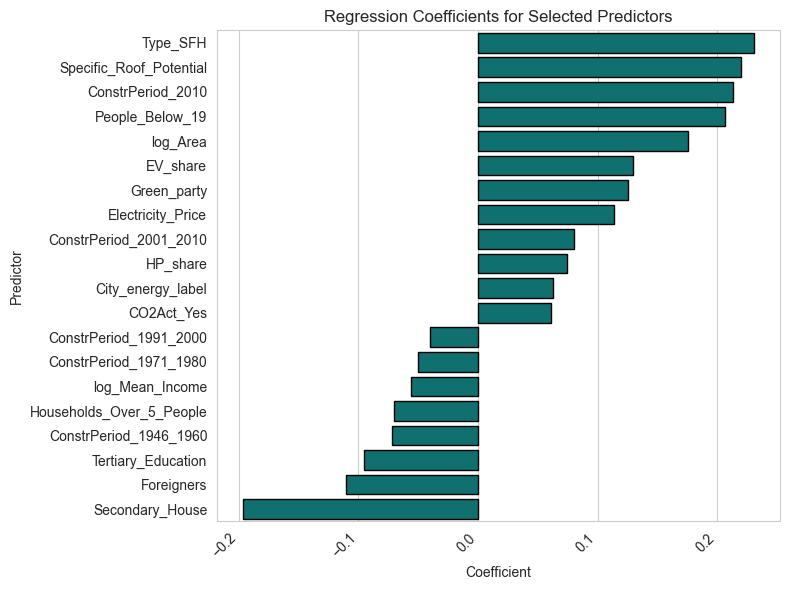

In [54]:
coef_series = final_model_PV.params
coef_series = coef_series[selected_vars_PV]
coef_df = coef_series.reset_index()
coef_df.columns = ["Predictor", "Coefficient"]
coef_df = coef_df.sort_values("Coefficient", ascending=False)

plt.figure(figsize=(8, 6))
sns.barplot(
    data=coef_df,
    x="Coefficient",
    y="Predictor",
    color="teal",
    edgecolor="black"
)

plt.xticks(rotation=45, ha="right")
plt.title("Regression Coefficients for Selected Predictors")
plt.tight_layout()
plt.show()

In [55]:
selected_vars_PV.remove('City_energy_label')

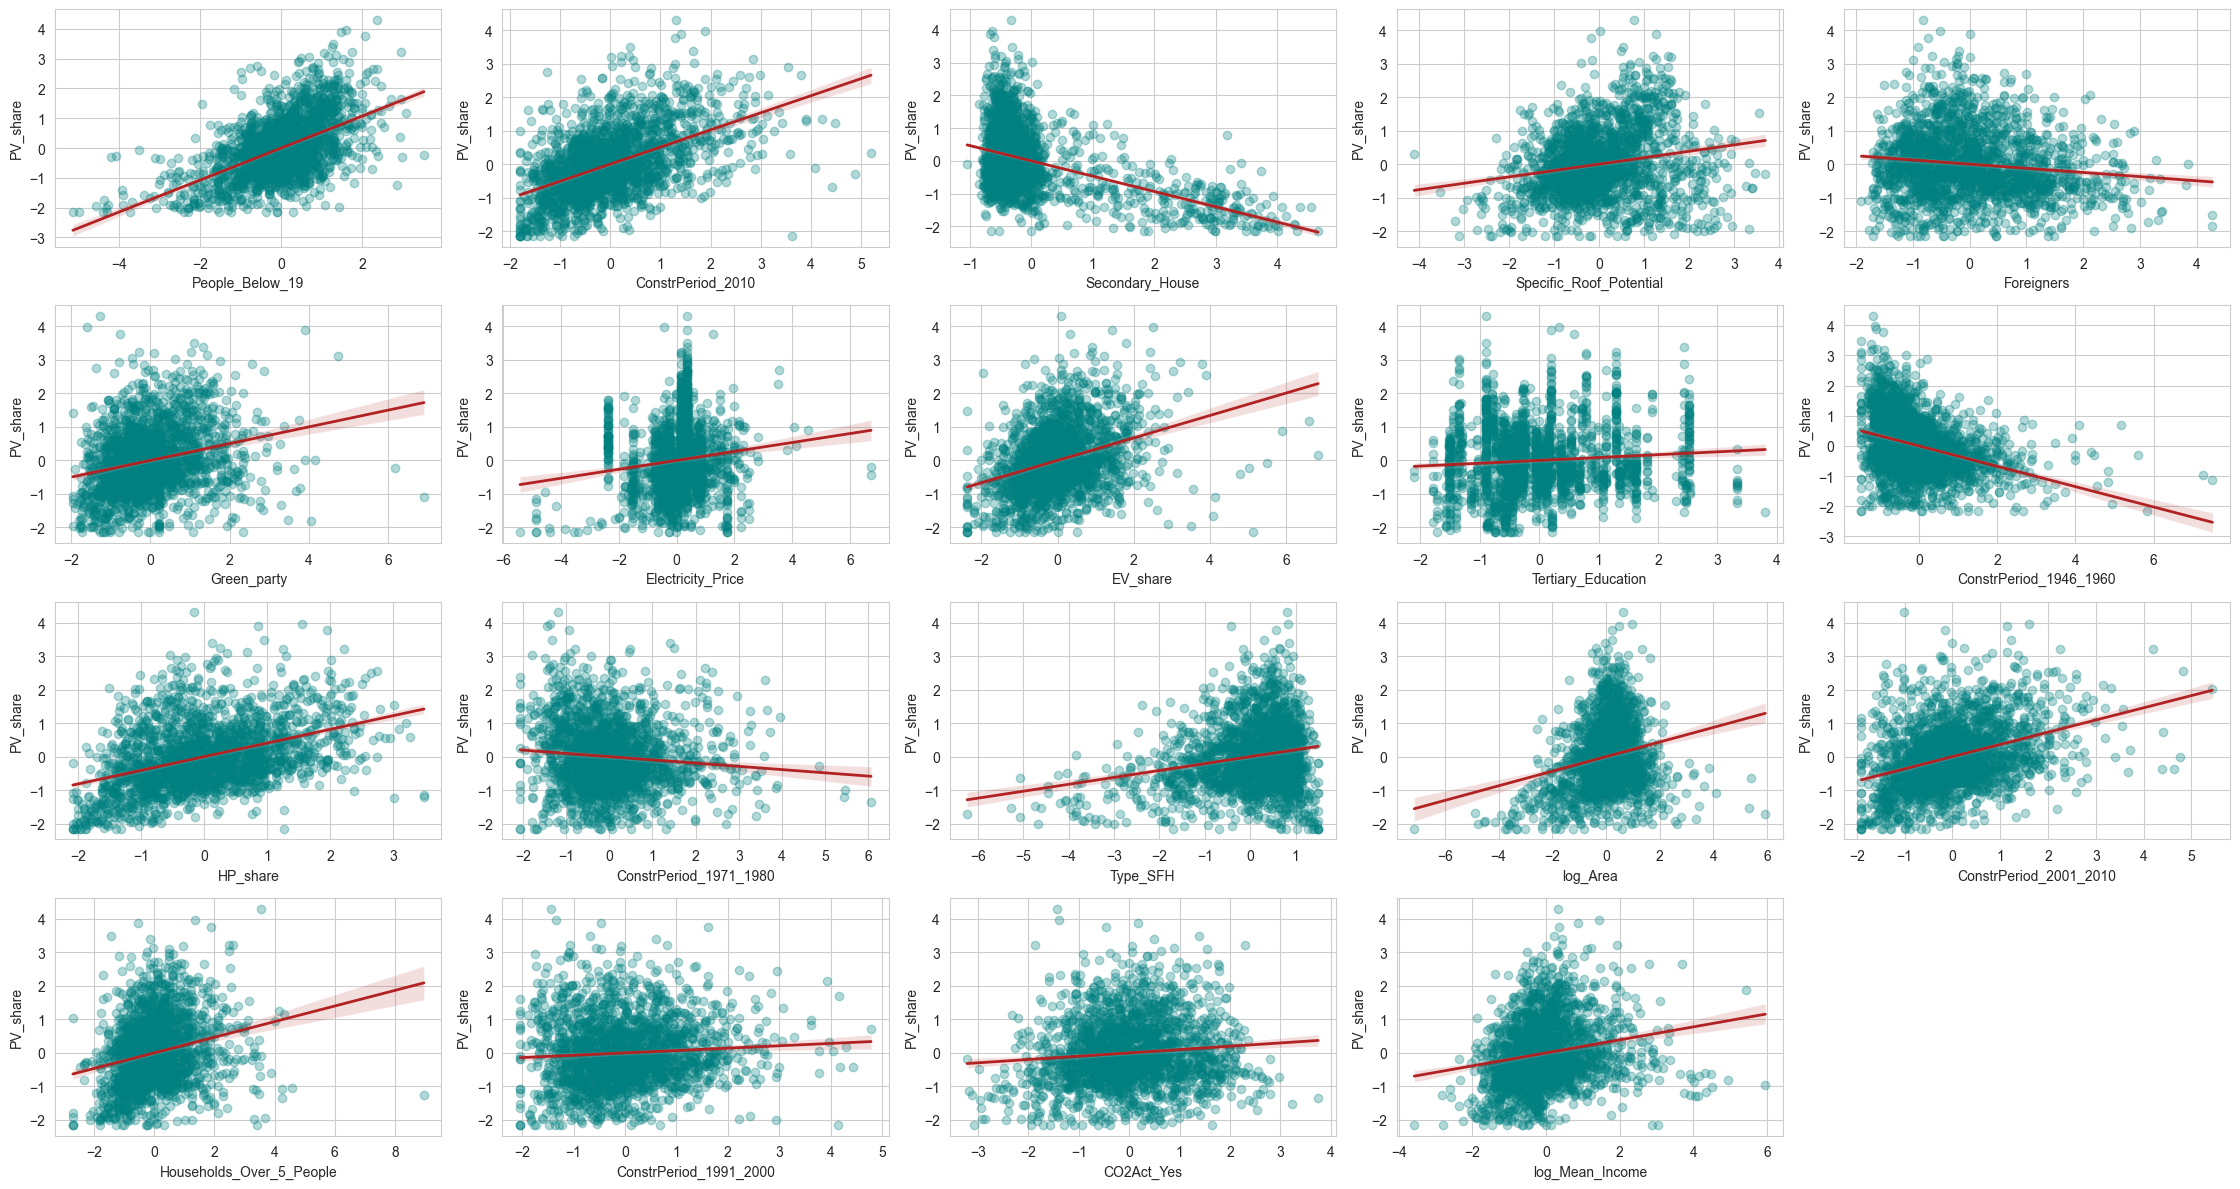

In [56]:
y = gdf_regression_mun["PV_share"]
predictors = selected_vars_PV

n = len(predictors)
cols = 5
rows = int(np.ceil(n / cols))

fig, axes = plt.subplots(rows, cols, figsize=(4.5*cols, 3*rows))
axes = axes.flatten()

for i, predictor in enumerate(predictors):
    ax = axes[i]

    sns.regplot(
        x=gdf_regression_mun[predictor],
        y=y,
        color='teal',
        scatter_kws={"alpha": 0.3},
        line_kws={"linewidth": 2, 'color': 'firebrick'},
        ax=ax
    )
    ax.set_xlabel(predictor)

for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [65]:
gdf_regression_mun["residuals"] = final_model_PV.resid
gdf_regression_mun["fitted"] = final_model_PV.fittedvalues
gdf_regression_mun["standardized_residuals"] = final_model_PV.get_influence().resid_studentized_internal

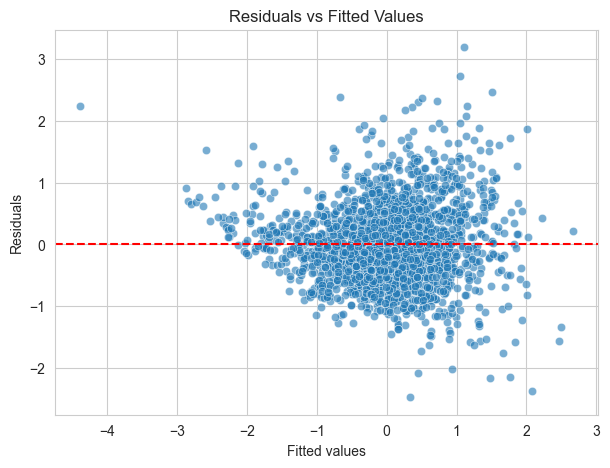

In [66]:
plt.figure(figsize=(7, 5))
sns.scatterplot(
    data=gdf_regression_mun,
    x="fitted", y="residuals",
    alpha=0.6
)
plt.axhline(0, color="red", linestyle="--")
plt.xlabel("Fitted values")
plt.ylabel("Residuals")
plt.title("Residuals vs Fitted Values")
plt.show()

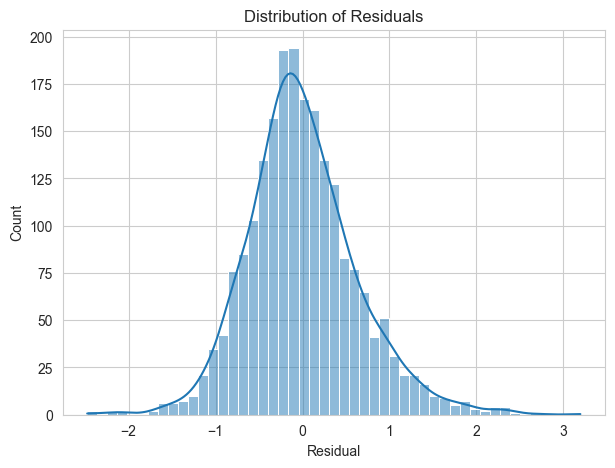

In [67]:
plt.figure(figsize=(7, 5))
sns.histplot(gdf_regression_mun["residuals"], kde=True)
plt.title("Distribution of Residuals")
plt.xlabel("Residual")
plt.show()


<Figure size 600x600 with 0 Axes>

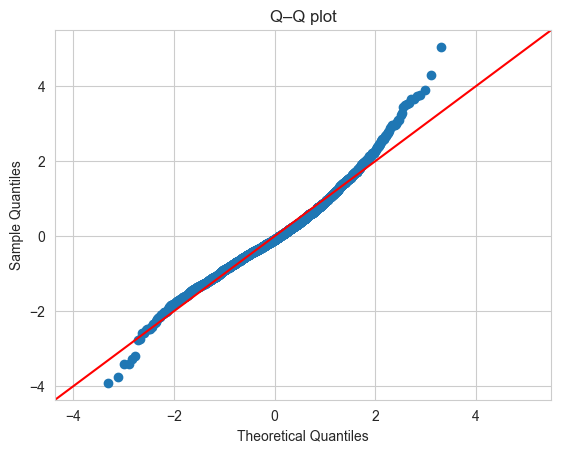

In [68]:
import statsmodels.api as sm

plt.figure(figsize=(6, 6))
sm.qqplot(gdf_regression_mun["residuals"], line="45", fit=True)
plt.title("Q–Q plot")
plt.show()

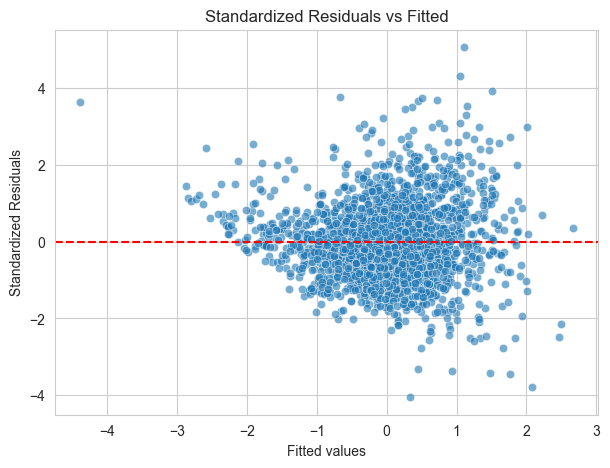

In [69]:
plt.figure(figsize=(7, 5))
sns.scatterplot(
    data=gdf_regression_mun,
    x="fitted", y="standardized_residuals",
    alpha=0.6
)
plt.axhline(0, color="red", linestyle="--")
plt.xlabel("Fitted values")
plt.ylabel("Standardized Residuals")
plt.title("Standardized Residuals vs Fitted")
plt.show()

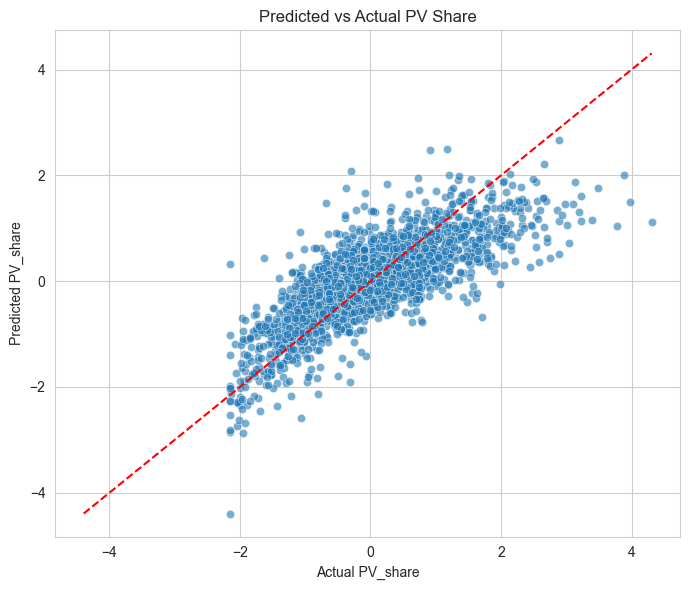

In [71]:
gdf_regression_mun["PV_pred"] = final_model_PV.fittedvalues

plt.figure(figsize=(7, 6))

sns.scatterplot(
    data=gdf_regression_mun,
    x="PV_share",        # actual values
    y="PV_pred",         # predicted values
    alpha=0.6,
)

# Add 45° reference line
min_val = min(gdf_regression_mun["PV_share"].min(), gdf_regression_mun["PV_pred"].min())
max_val = max(gdf_regression_mun["PV_share"].max(), gdf_regression_mun["PV_pred"].max())

plt.plot([min_val, max_val], [min_val, max_val], color="red", linestyle="--")

plt.xlabel("Actual PV_share")
plt.ylabel("Predicted PV_share")
plt.title("Predicted vs Actual PV Share")
plt.tight_layout()
plt.show()

## 3.2 HP

In [59]:
all_predictors_HP = [
    'log_Area',
    'EV_share',
    'City_energy_label',
    'Secondary_House',
    'Tertiary_Education',
    'People_Over_65',
    'People_Below_19',
    'Foreigners',
    'Households_Over_5_People',
    'Population Density',
    'CO2Act_Yes',
    'Green_party',
    'Electricity_Price',
    'log_Mean_Income',
    'PV_share',
    'DH_share',
    'ConstrPeriod_1921_1945',
    'ConstrPeriod_1946_1960',
    'ConstrPeriod_1961_1970',
    'ConstrPeriod_1971_1980',
    'ConstrPeriod_1981_1990',
    'ConstrPeriod_1991_2000',
    'ConstrPeriod_2001_2010',
    'ConstrPeriod_2010',
    'Type_SFH',
    'AreaType_2',
    'AreaType_3'
]

vif_mun = compute_vif_muni(gdf_regression_mun, all_predictors_HP)
print(vif_mun)

                    Variable       VIF
0                      const  8.379759
1                   log_Area  3.157405
2                   EV_share  1.742121
3          City_energy_label  1.295262
4            Secondary_House  2.782786
5         Tertiary_Education  2.098266
6             People_Over_65  3.583999
7            People_Below_19  3.621405
8                 Foreigners  2.343365
9   Households_Over_5_People  2.133623
10        Population Density  2.145032
11                CO2Act_Yes  3.035255
12               Green_party  1.770805
13         Electricity_Price  1.190288
14           log_Mean_Income  2.642162
15                  PV_share  2.306937
16                  DH_share  1.072673
17    ConstrPeriod_1921_1945  2.044300
18    ConstrPeriod_1946_1960  2.234594
19    ConstrPeriod_1961_1970  1.498108
20    ConstrPeriod_1971_1980  1.572211
21    ConstrPeriod_1981_1990  1.395377
22    ConstrPeriod_1991_2000  1.417828
23    ConstrPeriod_2001_2010  1.631334
24         ConstrPeriod_2

In [60]:
selected_vars_HP, history_df_mun = stepwise_selection_inference_ols(
    data=gdf_regression_mun,
    response='HP_share',
    predictors=all_predictors_HP,
    p_enter=0.05,
    p_remove=0.05,
    selection="AIC"
)

print("Selected predictors:", selected_vars_HP)

STEP 0: ADD → ConstrPeriod_2001_2010 (AIC = 5347.258)
STEP 1: ADD → ConstrPeriod_2010 (AIC = 4971.053)
STEP 2: ADD → ConstrPeriod_1991_2000 (AIC = 4683.164)
STEP 3: ADD → Type_SFH (AIC = 4580.532)
STEP 4: ADD → Secondary_House (AIC = 4486.921)
STEP 5: ADD → DH_share (AIC = 4413.994)
STEP 6: ADD → People_Over_65 (AIC = 4357.128)
STEP 7: ADD → ConstrPeriod_1981_1990 (AIC = 4328.257)
STEP 8: ADD → Green_party (AIC = 4305.949)
STEP 9: ADD → EV_share (AIC = 4280.485)
STEP 10: ADD → Electricity_Price (AIC = 4266.260)
STEP 11: ADD → Tertiary_Education (AIC = 4251.015)
STEP 12: ADD → Households_Over_5_People (AIC = 4238.365)
STEP 13: ADD → ConstrPeriod_1946_1960 (AIC = 4230.217)
STEP 14: ADD → Foreigners (AIC = 4209.748)
STEP 15: ADD → log_Area (AIC = 4200.644)
STEP 16: ADD → CO2Act_Yes (AIC = 4186.898)
STEP 17: ADD → City_energy_label (AIC = 4179.576)
STEP 18: ADD → AreaType_2 (AIC = 4174.724)
STEP 19: ADD → AreaType_3 (AIC = 4161.216)
STEP 20: ADD → ConstrPeriod_1971_1980 (AIC = 4157.465)
ST

In [61]:
final_formula_HP = 'HP_share' + " ~ " + " + ".join(selected_vars_HP)
final_model_HP = smf.ols(final_formula_HP, data=gdf_regression_mun).fit()
print(final_model_HP.summary())

                            OLS Regression Results                            
Dep. Variable:               HP_share   R-squared:                       0.594
Model:                            OLS   Adj. R-squared:                  0.589
Method:                 Least Squares   F-statistic:                     132.9
Date:                Fri, 12 Dec 2025   Prob (F-statistic):               0.00
Time:                        14:56:34   Log-Likelihood:                -2049.4
No. Observations:                2116   AIC:                             4147.
Df Residuals:                    2092   BIC:                             4283.
Df Model:                          23                                         
Covariance Type:            nonrobust                                         
                               coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------
Intercept               

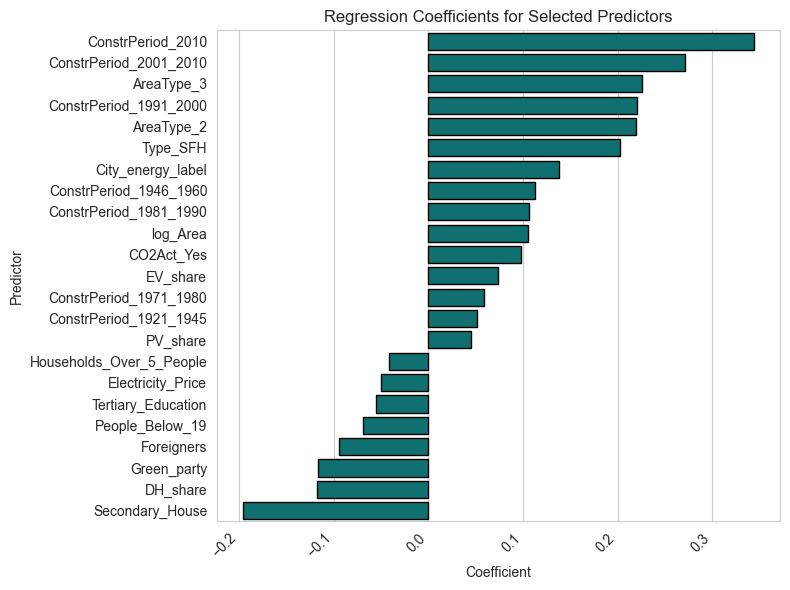

In [62]:
coef_series = final_model_HP.params
coef_series = coef_series[selected_vars_HP]
coef_df = coef_series.reset_index()
coef_df.columns = ["Predictor", "Coefficient"]
coef_df = coef_df.sort_values("Coefficient", ascending=False)

plt.figure(figsize=(8, 6))
sns.barplot(
    data=coef_df,
    x="Coefficient",
    y="Predictor",
    color="teal",
    edgecolor="black"
)

plt.xticks(rotation=45, ha="right")
plt.title("Regression Coefficients for Selected Predictors")
plt.tight_layout()
plt.show()

In [63]:
selected_vars_HP.remove('City_energy_label')
selected_vars_HP.remove('AreaType_3')
selected_vars_HP.remove('AreaType_2')

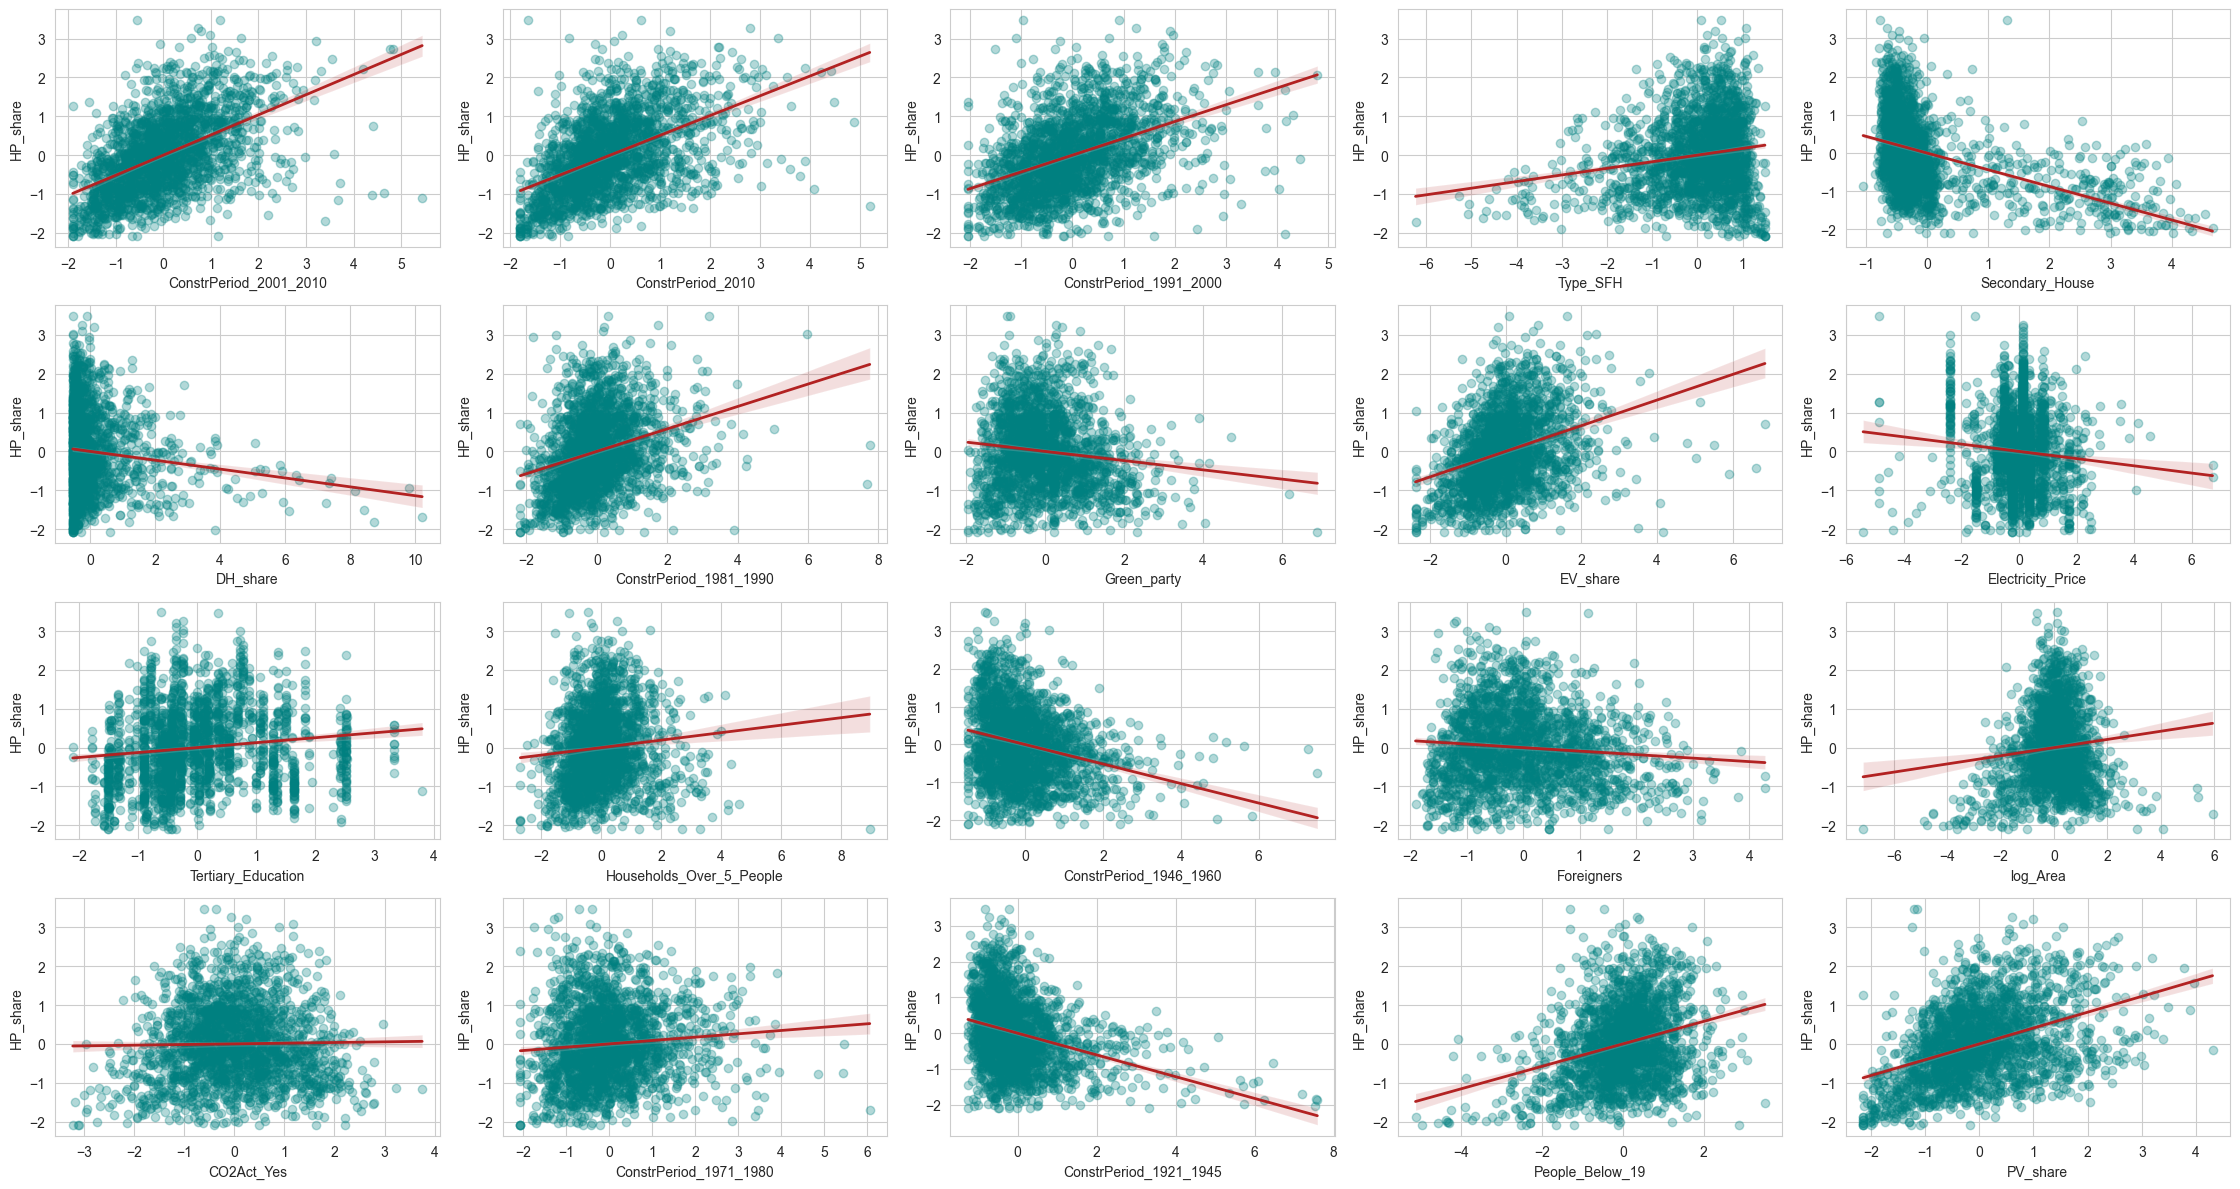

In [64]:
y = gdf_regression_mun["HP_share"]
predictors = selected_vars_HP

n = len(predictors)
cols = 5
rows = int(np.ceil(n / cols))

fig, axes = plt.subplots(rows, cols, figsize=(4.5*cols, 3*rows))
axes = axes.flatten()

for i, predictor in enumerate(predictors):
    ax = axes[i]

    sns.regplot(
        x=gdf_regression_mun[predictor],
        y=y,
        color='teal',
        scatter_kws={"alpha": 0.3},
        line_kws={"linewidth": 2, 'color': 'firebrick'},
        ax=ax
    )

    ax.set_xlabel(predictor)

for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

# 4. Spatial analysis

In [72]:
from libpysal.weights import DistanceBand, W, Queen
from libpysal.weights import Queen
from sklearn.metrics import pairwise_distances
from spreg import GM_Combo_Het
from spreg import SUR
import copy

In [73]:
gdf_spatial_analysis = gdf_regression_mun.copy()

In [74]:
shp_file_municipality_limits = 'swissBOUNDARIES3D_1_4_TLM_HOHEITSGEBIET.shp'

municipal_limits = gpd.read_file(notebook_dir + '/data/Limits/' + shp_file_municipality_limits)
municipal_limits = municipal_limits[['NAME', 'geometry']]
municipal_limits = municipal_limits.dissolve(by="NAME", as_index=False)
municipal_limits = municipal_limits.rename(columns={'NAME': 'Municipality'})
municipal_limits = municipal_limits.to_crs(epsg=2056)

In [75]:
gdf_spatial_analysis = gdf_spatial_analysis.merge(municipal_limits, on="Municipality", how="inner")
gdf_spatial_analysis = gpd.GeoDataFrame(gdf_spatial_analysis, geometry='geometry', crs=2056)

In [76]:
population_file = '/data/Drivers/resident_population_mun.csv'

df_population = pd.read_csv(
    notebook_dir + population_file, 
    sep=";", 
    skiprows=3,
    names=["Municipality", "Population"]
)

df_population["Population"] = pd.to_numeric(df_population["Population"], errors="coerce")

df_population = df_population[["Municipality", "Population"]].copy()

gdf_spatial_analysis = gdf_spatial_analysis.merge(
    df_population,
    how="left",
    on="Municipality"
)

gdf_spatial_analysis['Area_km2'] = gdf_spatial_analysis.geometry.area / 1e6
gdf_spatial_analysis = gdf_spatial_analysis.loc[:, ~gdf_spatial_analysis.columns.duplicated()]

_missing = gdf_spatial_analysis.loc[gdf_spatial_analysis["Population"].isna(), "Municipality"].unique()
print(f"Municipalities not matched: {len(_missing)}")

mean = gdf_spatial_analysis["Population"].mean()
gdf_spatial_analysis["Population"] = gdf_spatial_analysis["Population"].fillna(mean)

_missing = gdf_spatial_analysis.loc[gdf_spatial_analysis["Population"].isna(), "Municipality"].unique()
print(f"Municipalities not matched: {len(_missing)}")

Municipalities not matched: 0
Municipalities not matched: 0


In [77]:
gdf_area = gdf_spatial_analysis[['Municipality', 'Area_km2']].copy()

In [78]:
c_factor = 1.5

def build_W_matrix(gdf_clean):

    gdf_clean = gdf_clean.reset_index(drop=True)

    pop = gdf_clean["Population"].to_numpy()

    areas = gdf_clean.geometry.area.to_numpy()
    radii = c_factor * np.sqrt(areas)

    centroids = gdf_clean.geometry.centroid
    coords = np.column_stack([centroids.x.to_numpy(), centroids.y.to_numpy()])

    D = pairwise_distances(coords)

    neighbors = {}
    weights = {}
    alpha = -1.0

    n = len(gdf_clean)
    for i in range(n):

        mask = (D[i] > 0) & (D[i] <= radii[i])
        idxs = np.where(mask)[0].tolist()

        neighbors[i] = idxs

        w_i = []
        for j in idxs:
            d_ij = D[i, j]
            w_ij = (d_ij ** alpha) * pop[j]
            w_i.append(w_ij)
        weights[i] = w_i

    W_dist = W(neighbors, weights, silence_warnings=True)
    W_dist.transform = "R"

    W_queen = Queen.from_dataframe(gdf_clean, use_index=False)
    W_queen.transform = "R"

    W_queen_pop = copy.deepcopy(W_queen)

    for i, neighs in W_queen_pop.neighbors.items():
        new_weights = []
        for j in neighs:
            w_ij = pop[j]
            new_weights.append(w_ij)
        W_queen_pop.weights[i] = new_weights

    W_queen_pop.transform = "R"

    return W_dist, W_queen, W_queen_pop

In [79]:
def stepwise_selection_spatial_GMM(
    data,
    response,
    predictors,
    W_matrix,
    p_enter=0.05,
    p_remove=0.05,
    verbose=True
):
    """
    Stepwise selection for spatial GMM (GM_Combo_Het) regression.
    Returns selected predictors, history, and final p-values.
    """

    selected = []
    remaining = predictors.copy()
    history = []
    step = 0
    current_score = np.inf
    last_added_pvalue = None  # Track p-value of last added predictor

    def fit_gmm(y, X, specific_predictor=None):
        """
        Fit GM_Combo_Het and return:
        - model object
        - AIC score
        - dictionary of p-values for ALL predictors
        - optional: p-value for specific predictor if requested
        """
        model = GM_Combo_Het(
            y, X, w=W_matrix,
            name_y=response,
            name_x=list(X.columns),
            name_w="W_matrix"
        )
        n = X.shape[0]
        k = X.shape[1] + 1  # include intercept
        sigma2 = (model.u.T @ model.u / n).item()
        loglik = -0.5 * n * (np.log(2 * np.pi) + np.log(sigma2) + 1)
        aic = 2 * k - 2 * loglik

        # Extract p-values from z_stat (which is a list of tuples)
        p_values = {}

        # The order in z_stat matches the order of X.columns
        # Let's create a mapping first
        for i, predictor in enumerate(X.columns):
            if i < len(model.z_stat):
                # z_stat[i] is a tuple: (z-value, p-value)
                z_val, p_val = model.z_stat[i]
                p_values[predictor] = p_val
            else:
                p_values[predictor] = np.nan

        # Alternative approach if z_stat includes names
        # (depends on the specific implementation of GM_Combo_Het)
        if hasattr(model, 'name_x') and model.name_x:
            # Try to match predictors with z_stat using model.name_x
            for i, name in enumerate(model.name_x):
                if i < len(model.z_stat) and name in X.columns:
                    z_val, p_val = model.z_stat[i]
                    p_values[name] = p_val

        # Return p-value for specific predictor if requested
        if specific_predictor:
            return model, aic, p_values.get(specific_predictor, np.nan), p_values

        return model, aic, None, p_values

    while True:
        improved = False

        # ----------------- Forward step -----------------
        forward_candidates = []
        for cand in remaining:
            X_try = data[selected + [cand]]
            y_try = data[[response]]
            try:
                # Get p-value specifically for the candidate
                model, score, cand_pval, all_pvals = fit_gmm(y_try, X_try, specific_predictor=cand)

                # Check if candidate's p-value meets threshold
                if not np.isnan(cand_pval) and cand_pval < p_enter:
                    forward_candidates.append((score, cand, model, cand_pval, all_pvals))
            except Exception as e:
                if verbose:
                    print(f"Failed to fit model with {cand}: {e}")
                continue

        if forward_candidates:
            # Sort by AIC (lowest is best)
            forward_candidates.sort(key=lambda x: x[0])
            best_score, best_cand, best_model, best_pval, best_pvals = forward_candidates[0]

            if best_score < current_score:
                selected.append(best_cand)
                remaining.remove(best_cand)
                current_score = best_score
                last_added_pvalue = best_pval  # Store p-value of last added predictor
                step += 1
                improved = True

                if verbose:
                    print(f"STEP {step}: ADD → {best_cand} (AIC = {best_score:.2f}, p = {best_pval:.4f})")

                history.append({
                    "Step": step,
                    "Action": f"ADD {best_cand}",
                    "AIC": best_score,
                    "P_Value": best_pval,
                    "Included_Predictors": selected.copy()
                })

        # ----------------- Backward step (strict p-value removal) -----------------
        while True:
            if not selected:
                break

            X_current = data[selected]
            y_current = data[[response]]

            try:
                # Get p-values for all current predictors
                model_current, score_current, _, all_pvals = fit_gmm(y_current, X_current)
            except Exception as e:
                if verbose:
                    print(f"Backward step failed: {e}")
                break

            # Find predictors with p-value > p_remove
            to_remove = []
            for term in selected:
                pval = all_pvals.get(term, np.nan)
                if not np.isnan(pval) and pval > p_remove:
                    to_remove.append((term, pval))

            # Sort by p-value (highest first)
            to_remove.sort(key=lambda x: x[1], reverse=True)

            if not to_remove:
                break  # no predictors exceed p-value threshold

            # Remove all predictors with p > p_remove
            for term, pval in to_remove:
                selected.remove(term)
                remaining.append(term)
                step += 1
                improved = True
                current_score = score_current

                if verbose:
                    print(f"STEP {step}: REMOVE → {term} (p = {pval:.4f})")

                history.append({
                    "Step": step,
                    "Action": f"REMOVE {term}",
                    "AIC": score_current,
                    "P_Value": pval,
                    "Included_Predictors": selected.copy()
                })

        if not improved:
            break

    history_df = pd.DataFrame(history)

    return selected, history_df

## 4.1 PV

In [80]:
columns_pv = selected_vars_PV

gdf_sa_pv_clean = gdf_spatial_analysis.dropna(subset=columns_pv + ["PV_share"]).reset_index(drop=True)

W_dist_pv, W_queen_pv, W_queen_pop_pv = build_W_matrix(gdf_sa_pv_clean)

selected_predictors, history_df = stepwise_selection_spatial_GMM(
    data=gdf_sa_pv_clean,
    response="PV_share",
    predictors=columns_pv,
    W_matrix=W_dist_pv,
    p_enter=0.05,
    p_remove=0.05,
    verbose=True
)

print("Final selected predictors:", selected_predictors)

STEP 1: ADD → People_Below_19 (AIC = 3985.71, p = 0.0000)
STEP 2: ADD → HP_share (AIC = 3835.59, p = 0.0000)
STEP 3: ADD → Electricity_Price (AIC = 3791.55, p = 0.0000)
STEP 4: ADD → Specific_Roof_Potential (AIC = 3728.39, p = 0.0000)
STEP 5: ADD → EV_share (AIC = 3693.00, p = 0.0000)
STEP 6: ADD → Foreigners (AIC = 3635.53, p = 0.0000)
STEP 7: ADD → ConstrPeriod_2010 (AIC = 3576.11, p = 0.0000)
STEP 8: ADD → Green_party (AIC = 3539.01, p = 0.0000)
STEP 9: ADD → Secondary_House (AIC = 3505.79, p = 0.0000)
STEP 10: ADD → Tertiary_Education (AIC = 3482.35, p = 0.0008)
STEP 11: ADD → ConstrPeriod_2001_2010 (AIC = 3471.51, p = 0.0023)
Final selected predictors: ['People_Below_19', 'HP_share', 'Electricity_Price', 'Specific_Roof_Potential', 'EV_share', 'Foreigners', 'ConstrPeriod_2010', 'Green_party', 'Secondary_House', 'Tertiary_Education', 'ConstrPeriod_2001_2010']


In [81]:
X_final = gdf_sa_pv_clean[selected_predictors]
y_final = gdf_sa_pv_clean[["PV_share"]]

final_model = GM_Combo_Het(
    y_final,
    X_final,
    w=W_dist_pv,
    name_y="PV_share",
    name_x=selected_predictors,
    name_w="W_dist_pv"
)

print(final_model.summary)

REGRESSION RESULTS
------------------

SUMMARY OF OUTPUT: SPATIALLY WEIGHTED 2SLS- GM-COMBO MODEL (HET)
----------------------------------------------------------------
Data set            :     unknown
Weights matrix      :   W_dist_pv
Dependent Variable  :    PV_share                Number of Observations:        2111
Mean dependent var  :      0.0002                Number of Variables   :          13
S.D. dependent var  :      0.9993                Degrees of Freedom    :        2098
Pseudo R-squared    :      0.7006
Spatial Pseudo R-squared:  0.5982
N. of iterations    :           1                Step1c computed       :          No

------------------------------------------------------------------------------------
            Variable     Coefficient       Std.Error     z-Statistic     Probability
------------------------------------------------------------------------------------
            CONSTANT         0.00102         0.01295         0.07861         0.93735
     People_Be

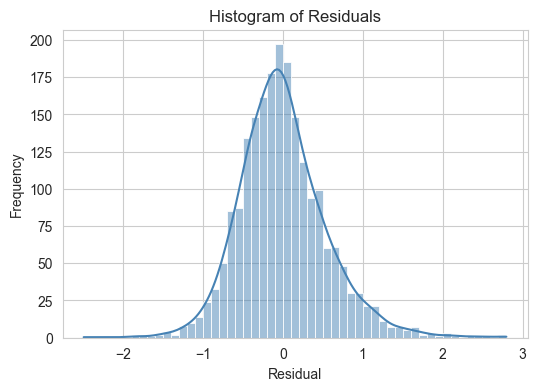

In [82]:
residuals = final_model.u
fitted = final_model.predy

plt.figure(figsize=(6,4))
sns.histplot(residuals.flatten(), kde=True, color="steelblue")
plt.title("Histogram of Residuals")
plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.show()

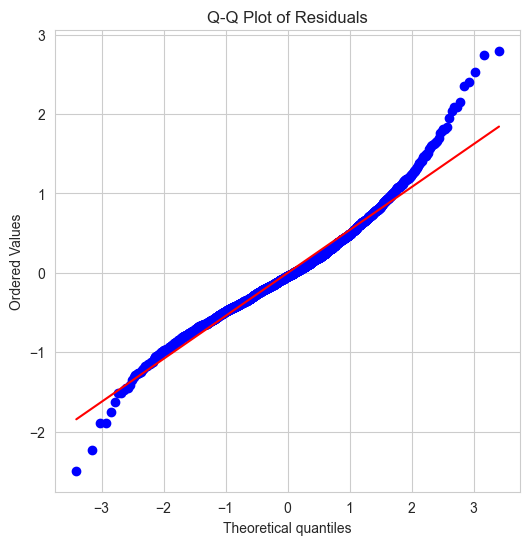

In [83]:
import scipy.stats as stats

plt.figure(figsize=(6,6))
stats.probplot(residuals.flatten(), dist="norm", plot=plt)
plt.title("Q-Q Plot of Residuals")
plt.show()

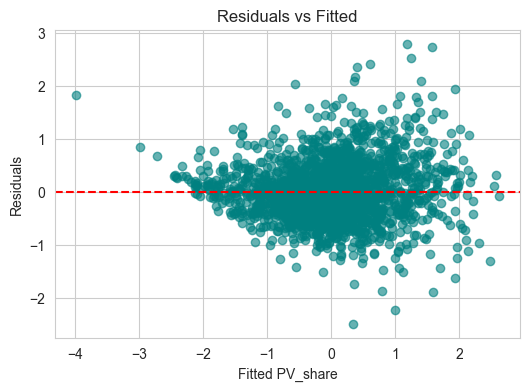

In [84]:
plt.figure(figsize=(6,4))
plt.scatter(fitted, residuals, alpha=0.6, color="teal")
plt.axhline(0, color="red", linestyle="--")
plt.xlabel("Fitted PV_share")
plt.ylabel("Residuals")
plt.title("Residuals vs Fitted")
plt.show()

In [85]:
import esda

resid_array = residuals.flatten()
mi = esda.Moran(resid_array, W_dist_pv)
print(f"Moran's I: {mi.I:.4f}, p-value: {mi.p_sim:.4f}")

Moran's I: 0.0427, p-value: 0.0040


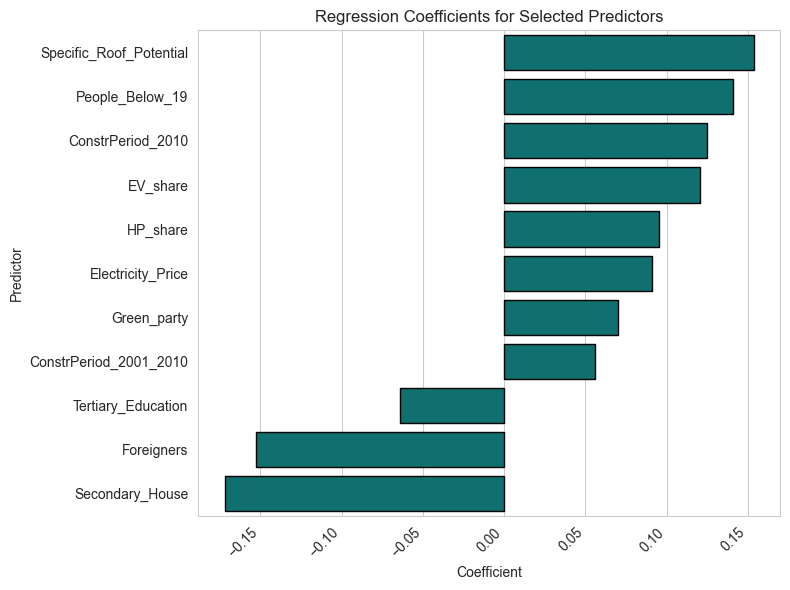

In [201]:
coef_series = pd.DataFrame(final_model.betas).rename(columns={0: 'Coefficient'})
predictors_x = final_model.name_x + ['W_PV_share', 'lambda']
coef_series['Predictor'] = predictors_x
coef_df = coef_series.sort_values("Coefficient", ascending=False)
coef_df = coef_df[~coef_df['Predictor'].isin(['W_PV_share', 'CONSTANT', 'lambda'])]

plt.figure(figsize=(8, 6))
sns.barplot(
    data=coef_df,
    x="Coefficient",
    y="Predictor",
    color="teal",
    edgecolor="black"
)

plt.xticks(rotation=45, ha="right")
plt.title("Regression Coefficients for Selected Predictors")
plt.tight_layout()
plt.show()

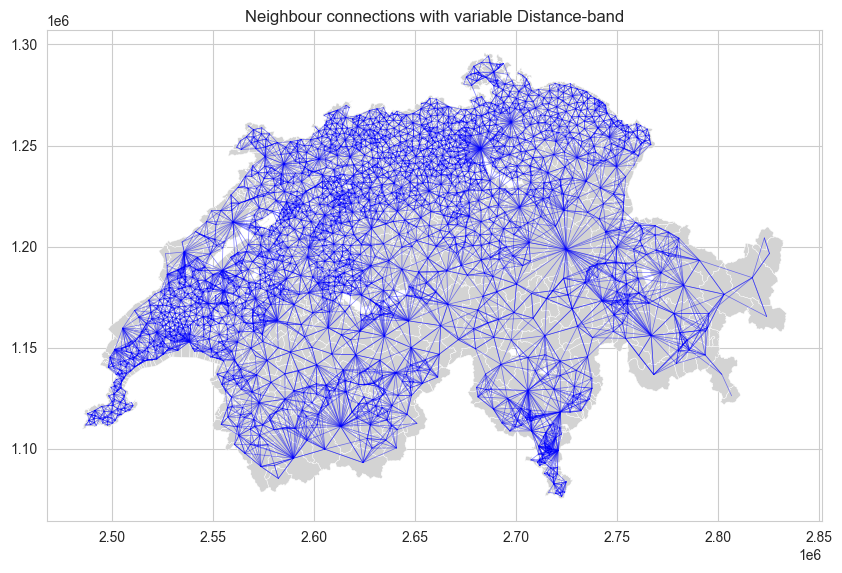

In [178]:
coords = gdf_sa_pv_clean.geometry.centroid

fig, ax = plt.subplots(figsize=(10, 10))

gdf_sa_pv_clean.plot(ax=ax, facecolor="lightgray", edgecolor="white", linewidth=0.3)

for i, neighbors in W_dist_pv.neighbors.items():
    xi, yi = coords.iloc[i].x, coords.iloc[i].y
    for j in neighbors:
        xj, yj = coords.iloc[j].x, coords.iloc[j].y
        ax.plot([xi, xj], [yi, yj], linewidth=0.5, color="blue", alpha=0.5)

plt.title("Neighbour connections with variable Distance-band")
plt.show()

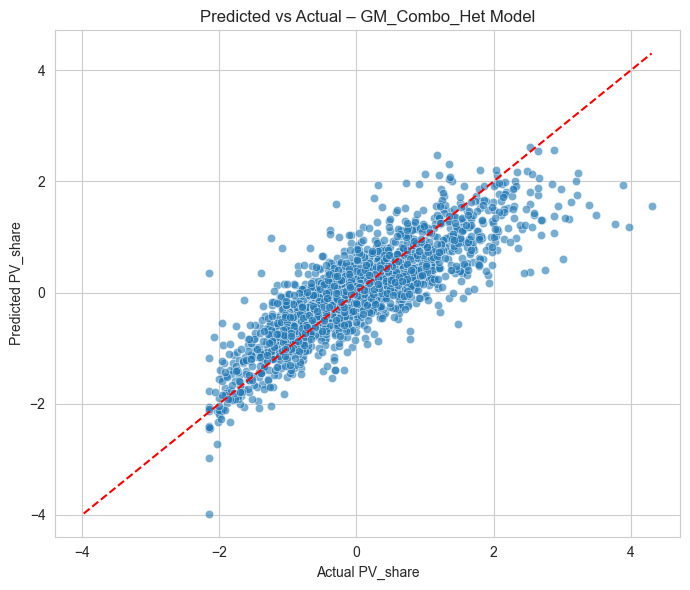

In [86]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Extract actual + predicted values
actual = np.array(final_model.y).flatten()
predicted = np.array(final_model.predy).flatten()

plt.figure(figsize=(7, 6))

sns.scatterplot(
    x=actual,
    y=predicted,
    alpha=0.6
)

# 45-degree reference line
min_val = min(actual.min(), predicted.min())
max_val = max(actual.max(), predicted.max())
plt.plot([min_val, max_val], [min_val, max_val], color="red", linestyle="--")

plt.xlabel("Actual PV_share")
plt.ylabel("Predicted PV_share")
plt.title("Predicted vs Actual – GM_Combo_Het Model")
plt.tight_layout()
plt.show()

## 4.2 HP

In [209]:
columns_hp = selected_vars_HP

gdf_sa_hp_clean = gdf_spatial_analysis.dropna(subset=columns_hp + ["HP_share"]).reset_index(drop=True)

W_dist, W_queen, W_queen_pop = build_W_matrix(gdf_sa_hp_clean)

selected_predictors, history_df = stepwise_selection_spatial_GMM(
    data=gdf_sa_hp_clean,
    response="HP_share",
    predictors=columns_hp,
    W_matrix=W_dist,
    p_enter=0.05,
    p_remove=0.05,
    verbose=True
)

print("Final selected predictors:", selected_predictors)

STEP 1: ADD → ConstrPeriod_2001_2010 (AIC = 4250.86, p = 0.0000)
STEP 2: ADD → ConstrPeriod_1991_2000 (AIC = 4186.62, p = 0.0000)
STEP 3: ADD → ConstrPeriod_2010 (AIC = 4017.81, p = 0.0000)
STEP 4: ADD → Type_SFH (AIC = 3969.46, p = 0.0000)
STEP 5: ADD → Households_Over_5_People (AIC = 3928.69, p = 0.0000)
STEP 6: ADD → DH_share (AIC = 3904.96, p = 0.0000)
STEP 7: ADD → Secondary_House (AIC = 3882.11, p = 0.0000)
STEP 8: ADD → Electricity_Price (AIC = 3842.01, p = 0.0031)
STEP 9: ADD → Green_party (AIC = 3823.27, p = 0.0134)
STEP 10: ADD → CO2Act_Yes (AIC = 3790.22, p = 0.0000)
STEP 11: ADD → Foreigners (AIC = 3779.96, p = 0.0000)
STEP 12: ADD → ConstrPeriod_1971_1980 (AIC = 3769.57, p = 0.0001)
STEP 13: REMOVE → Electricity_Price (p = 0.0840)
STEP 14: ADD → ConstrPeriod_1946_1960 (AIC = 3740.11, p = 0.0412)
STEP 15: ADD → log_Area (AIC = 3723.80, p = 0.0016)
STEP 16: ADD → ConstrPeriod_1981_1990 (AIC = 3708.91, p = 0.0000)
STEP 17: ADD → EV_share (AIC = 3698.32, p = 0.0034)
STEP 18: A

In [210]:
X_final = gdf_sa_hp_clean[selected_predictors]
y_final = gdf_sa_hp_clean[["HP_share"]]

final_model = GM_Combo_Het(
    y_final,
    X_final,
    w=W_dist,
    name_y="HP_share",
    name_x=selected_predictors,
    name_w="W_dist"
)

print(final_model.summary)

REGRESSION RESULTS
------------------

SUMMARY OF OUTPUT: SPATIALLY WEIGHTED 2SLS- GM-COMBO MODEL (HET)
----------------------------------------------------------------
Data set            :     unknown
Weights matrix      :      W_dist
Dependent Variable  :    HP_share                Number of Observations:        2111
Mean dependent var  :      0.0009                Number of Variables   :          18
S.D. dependent var  :      0.9993                Degrees of Freedom    :        2093
Pseudo R-squared    :      0.6702
Spatial Pseudo R-squared:  0.5835
N. of iterations    :           1                Step1c computed       :          No

------------------------------------------------------------------------------------
            Variable     Coefficient       Std.Error     z-Statistic     Probability
------------------------------------------------------------------------------------
            CONSTANT         0.00658         0.01827         0.36018         0.71871
ConstrPeriod_2

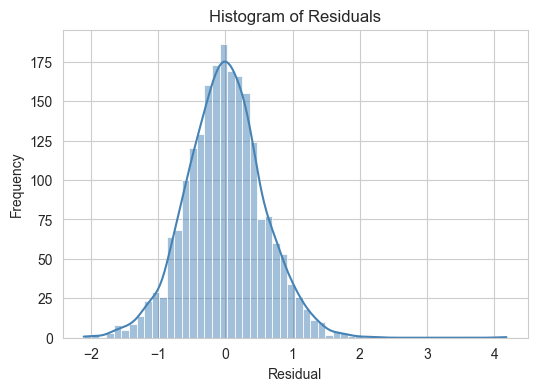

In [211]:
residuals = final_model.u
fitted = final_model.predy

plt.figure(figsize=(6, 4))
sns.histplot(residuals.flatten(), kde=True, color="steelblue")
plt.title("Histogram of Residuals")
plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.show()

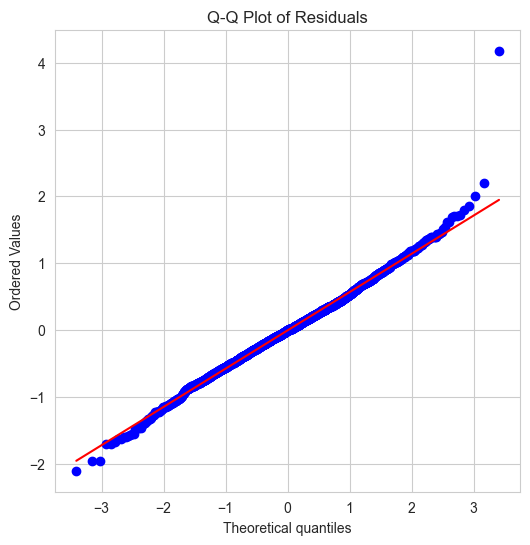

In [213]:
plt.figure(figsize=(6, 6))
stats.probplot(residuals.flatten(), dist="norm", plot=plt)
plt.title("Q-Q Plot of Residuals")
plt.show()

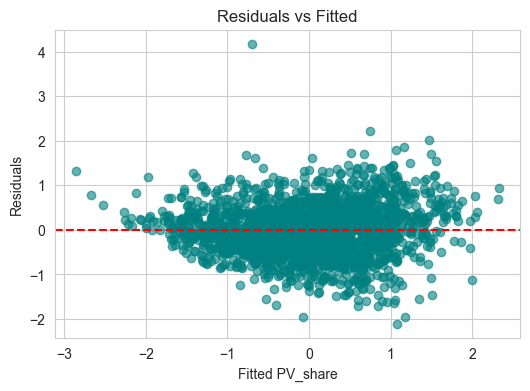

In [214]:
plt.figure(figsize=(6, 4))
plt.scatter(fitted, residuals, alpha=0.6, color="teal")
plt.axhline(0, color="red", linestyle="--")
plt.xlabel("Fitted PV_share")
plt.ylabel("Residuals")
plt.title("Residuals vs Fitted")
plt.show()

In [215]:
resid_array = residuals.flatten()
mi = esda.Moran(resid_array, W_dist_pv)
print(f"Moran's I: {mi.I:.4f}, p-value: {mi.p_sim:.4f}")

Moran's I: 0.2165, p-value: 0.0010


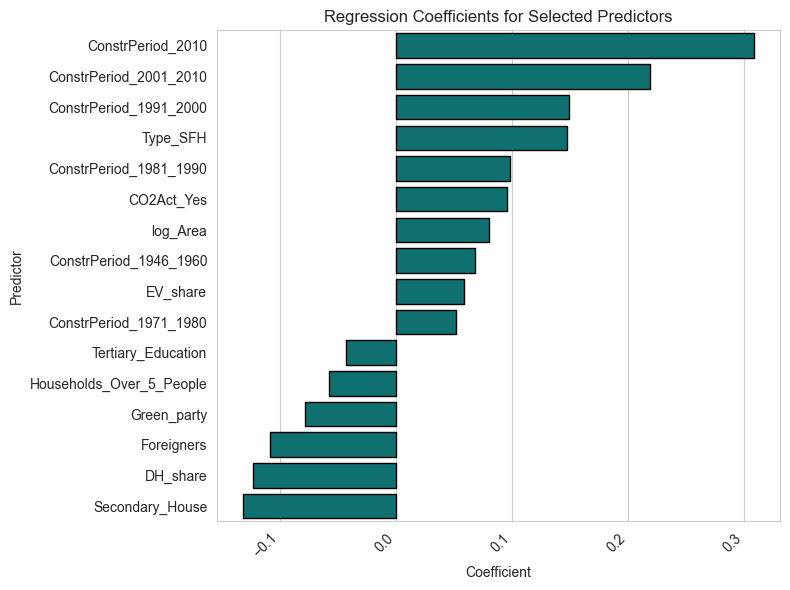

In [217]:
coef_series = pd.DataFrame(final_model.betas).rename(columns={0: 'Coefficient'})
predictors_x = final_model.name_x + ['W_HP_share', 'lambda']
coef_series['Predictor'] = predictors_x
coef_df = coef_series.sort_values("Coefficient", ascending=False)
coef_df = coef_df[~coef_df['Predictor'].isin(['W_HP_share', 'CONSTANT', 'lambda'])]

plt.figure(figsize=(8, 6))
sns.barplot(
    data=coef_df,
    x="Coefficient",
    y="Predictor",
    color="teal",
    edgecolor="black"
)

plt.xticks(rotation=45, ha="right")
plt.title("Regression Coefficients for Selected Predictors")
plt.tight_layout()
plt.show()